# Event-Aware Promotion Decisions: Propensity, Uplift, and Policy

**Phiên bản hợp nhất v2** — nền là pipeline `v1_1` (xử lý dữ liệu chặt, không rò rỉ),
bổ sung tầng uplift/CATE viết lại từ đầu thay cho bản trong `Uplift_Promotion_Pipeline`.

## Những lỗi đã sửa so với hai bản cũ

| # | Lỗi | Ở đâu | Cách sửa trong bản này |
|---|-----|-------|------------------------|
| 1 | GRU encoder **không được huấn luyện** — `H = gru_encoder.predict(...)` trên trọng số ngẫu nhiên, toàn bộ CATE chạy trên đặc trưng vô nghĩa | Uplift NB 10.3–10.4 | Encoder được huấn luyện end-to-end; embedding chỉ trích xuất sau khi fit |
| 2 | **Lệch thứ tự hàng**: `behavior_features` sắp theo `session_id` nhưng gán `decision_id` sắp theo `event_time` → đặc trưng khớp sai nhãn | Uplift NB 9.2 | Mọi đặc trưng gắn theo chỉ số hàng của `dp`, có assert kiểm tra |
| 3 | **Treatment nằm trong X**: `price`, `reference_price`, `price_deviation` là hiệp biến trong khi `T = 1[1 − price/ref ≥ 0.05]` → vi phạm positivity hoàn toàn | Uplift NB 9.4 + 8.3 | Tách hẳn `INVAR` (hiệp biến) và `TREAT`; bỏ `price` thô; kiểm tra overlap bằng propensity |
| 4 | **Mô phỏng what-if rỗng nghĩa**: `profit = tau_hat × price × (1−d)`, `tau_hat` không phụ thuộc `d` → nghiệm tối ưu luôn là `d = 0` do cấu trúc công thức | Uplift NB 12.3 | τ̂ ước lượng theo từng mức `d` quan sát được; lợi nhuận tính trên **biên**, không trên doanh thu |
| 5 | **Scaler fit trên toàn bộ dữ liệu** trước khi chia | Uplift NB 10.5 | Chuẩn hoá chỉ fit trên train |
| 6 | **Multi-seed dùng `train_test_split` ngẫu nhiên**, phá thiết kế thời gian | Uplift NB 13.2 | Đa seed giữ nguyên split thời gian, chỉ đổi seed khởi tạo mô hình |
| 7 | Chia dữ liệu **vá chồng vá** (chia theo tháng rồi chia lại theo ngày, khôi phục rồi chuẩn hoá lại) | v1_1 Block 7–12 | Gộp thành một cell duy nhất, có cờ `SPLIT_MODE` |
| 8 | Không có Qini/AUUC, không đánh giá được chính sách | Cả hai | Qini/AUUC đúng định nghĩa + policy value bằng IPW |

> **Lưu ý khi chạy:** notebook này chưa được chạy end-to-end (môi trường soạn thảo
> không có dataset). Mỗi stage đều có ô kiểm tra in ra số liệu — hãy đối chiếu trước
> khi chạy stage kế tiếp.

## Stage 0 — Cấu hình tập trung

In [1]:
# =====================================================================
# CONFIG — nguồn sự thật duy nhất. Mọi tham số nằm ở đây.
# =====================================================================
CONFIG = {
    # --- Dữ liệu ---
    "kaggle_dataset": "mkechinov/ecommerce-events-history-in-cosmetics-shop",
    "out_dir":        ".",
    "chunk":          2_000_000,
    "sample_user_mod": None,   # 10 -> lấy 10% user để chạy thử; None = toàn bộ

    # --- Nhãn ---
    "decision_event": "cart",
    "purchase_event": "purchase",
    "outcome_window_minutes": 120,

    # --- Chuỗi hành vi ---
    "max_len":        20,      # xuyên session (bản cũ dùng 4, trong session)
    "window_days":    7,
    "lookback_rows":  200,

    # --- Giá / treatment ---
    "ref_window_days": 14,     # cửa sổ giá tham chiếu
    "treat_threshold": 0.05,   # d >= 5% coi là treated
    "d_grid":         [0.00, 0.075, 0.125, 0.175, 0.25],

    # --- Chia dữ liệu ---
    # "chronological": khối thời gian sạch (chuẩn học thuật, ưu tiên)
    # "within_day"   : cắt trong từng ngày (giảm lệch tỷ lệ treated, phải biện luận)
    "split_mode":     "chronological",
    "train_frac":     0.70,
    "val_frac":       0.15,

    # --- Mô hình ---
    "emb": 16, "units": 32, "dense": 32, "dropout": 0.2, "lr": 1e-3,
    "epochs": 30, "batch_size": 4096, "patience": 3,

    # --- Đánh giá ---
    "gru_use_cudnn": "auto",   # đặt False nếu GPU vẫn báo lỗi mask
    "seeds":       [42, 43, 44, 45, 46],
    "top_k":       [0.05, 0.10, 0.20],
    "n_bootstrap": 1000,

    # --- Kinh tế ---
    "margin_rate": 0.30,       # biên lợi nhuận gộp khi KHÔNG giảm giá
    "subsample":   None,       # đặt số để chạy thử nhanh, None = toàn bộ
}

EVENTS  = ["view", "cart", "remove_from_cart", "purchase"]
EV2CODE = {e: i + 1 for i, e in enumerate(EVENTS)}   # 0 = padding
VOCAB   = len(EVENTS) + 1
OUT     = CONFIG["out_dir"]

for k, v in CONFIG.items():
    print(f"{k:24s} {v}")

kaggle_dataset           mkechinov/ecommerce-events-history-in-cosmetics-shop
out_dir                  .
chunk                    2000000
sample_user_mod          None
decision_event           cart
purchase_event           purchase
outcome_window_minutes   120
max_len                  20
window_days              7
lookback_rows            200
ref_window_days          14
treat_threshold          0.05
d_grid                   [0.0, 0.075, 0.125, 0.175, 0.25]
split_mode               chronological
train_frac               0.7
val_frac                 0.15
emb                      16
units                    32
dense                    32
dropout                  0.2
lr                       0.001
epochs                   30
batch_size               4096
patience                 3
gru_use_cudnn            auto
seeds                    [42, 43, 44, 45, 46]
top_k                    [0.05, 0.1, 0.2]
n_bootstrap              1000
margin_rate              0.3
subsample                None


## Stage 1 — Nạp và làm sạch dữ liệu

Đọc theo chunk để không vỡ RAM. Loại giá phi lý và bản ghi trùng.

In [2]:
import os, glob, gc, json, time, random
import numpy as np
import pandas as pd

def set_seed(s):
    random.seed(s); np.random.seed(s)
    try:
        import tensorflow as tf
        tf.keras.utils.set_random_seed(s)
    except Exception:
        pass

try:
    BASE
except NameError:
    import kagglehub
    BASE = kagglehub.dataset_download(CONFIG["kaggle_dataset"])

files = sorted(glob.glob(os.path.join(BASE, "**", "*.csv"), recursive=True))
files = [f for f in files if os.path.getsize(f) > 1_000_000]
print(f"BASE = {BASE}\nSố file: {len(files)}")

BASE = /home/jovyan/.cache/kagglehub/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/versions/6
Số file: 5


In [3]:
COLS = ["event_time", "event_type", "product_id", "brand", "price", "user_id"]
DT   = {"event_type": "category", "product_id": "int64", "price": "float32",
        "user_id": "int64", "brand": "category"}

parts, n_raw, n_bad, n_dup = [], 0, 0, 0
for f in files:
    print(f"  đọc {os.path.basename(f)}")
    for ch in pd.read_csv(f, usecols=COLS, dtype=DT, chunksize=CONFIG["chunk"]):
        n_raw += len(ch)
        if CONFIG["sample_user_mod"]:
            ch = ch.loc[ch["user_id"] % CONFIG["sample_user_mod"] == 0]
        bad = ~(ch["price"] > 0)
        n_bad += int(bad.sum())
        ch = ch.loc[~bad].copy()
        b0 = len(ch)
        ch = ch.drop_duplicates(
            subset=["user_id", "product_id", "event_type", "event_time"])
        n_dup += b0 - len(ch)
        ch["ts"] = pd.to_datetime(ch["event_time"].str.slice(0, 19),
                                  format="%Y-%m-%d %H:%M:%S")
        parts.append(ch[["user_id", "product_id", "event_type", "ts", "price"]])
        del ch
    gc.collect()

ev = pd.concat(parts, ignore_index=True)
del parts; gc.collect()

ev = ev.sort_values(["user_id", "ts"], kind="mergesort").reset_index(drop=True)
ev["date"]  = ev["ts"].dt.normalize()
ev["ecode"] = ev["event_type"].map(EV2CODE).astype("int8")

print(f"\nDòng thô {n_raw:,} | loại price<=0 {n_bad:,} | khử trùng {n_dup:,}")
print(f"Còn lại {len(ev):,} | user {ev.user_id.nunique():,} "
      f"| product {ev.product_id.nunique():,}")
print(f"Khoảng thời gian: {ev.ts.min()} -> {ev.ts.max()}")
print("\nPhân bố loại sự kiện:")
print(ev["event_type"].value_counts().to_string())

  đọc 2019-Dec.csv
  đọc 2019-Nov.csv
  đọc 2019-Oct.csv
  đọc 2020-Feb.csv
  đọc 2020-Jan.csv

Dòng thô 20,692,840 | loại price<=0 104,288 | khử trùng 1,099,399
Còn lại 19,489,153 | user 1,637,977 | product 53,904
Khoảng thời gian: 2019-10-01 00:00:00 -> 2020-02-29 23:59:59

Phân bố loại sự kiện:
event_type
view                9618242
cart                5615608
remove_from_cart    2969360
purchase            1285943


## Stage 2 — Giá tham chiếu và treatment (không rò rỉ)

Giá tham chiếu của sản phẩm tại ngày *D* = trung vị giá trong `ref_window_days`
ngày **trước đó** (`shift(1)` trước khi `rolling`). Không có thông tin của chính
ngày *D* hay tương lai lọt vào.

`d = 1 − price_D / ref_D` là mức giảm giá quan sát được, `treated = 1[d ≥ ngưỡng]`.

> **Cảnh báo phương pháp:** đây là *treatment proxy* từ biến động giá quan sát, không
> phải khuyến mãi ngẫu nhiên hoá. Mọi kết luận nhân quả phải kèm giả định
> *unconfoundedness* và được kiểm tra bằng overlap ở Stage 7.

In [4]:
REF_WIN = CONFIG["ref_window_days"]

pxd = (ev.groupby(["product_id", "date"], observed=True)["price"]
         .median().rename("p_med").reset_index()
         .sort_values(["product_id", "date"]))

g = pxd.groupby("product_id")["p_med"]
# shift(1) TRƯỚC rolling -> chỉ dùng quá khứ
pxd["ref"] = g.transform(lambda s: s.shift(1)
                                    .rolling(REF_WIN, min_periods=5).median())
pxd["cv"]  = g.transform(lambda s: s.shift(1).rolling(30, min_periods=7).std()
                                 / s.shift(1).rolling(30, min_periods=7).mean())
pxd["disc"] = (1 - pxd["p_med"] / pxd["ref"]).clip(lower=0, upper=0.95)
pxd["days_since_chg"] = g.transform(
    lambda s: s.groupby((s != s.shift()).cumsum()).cumcount())

d = pxd["disc"].dropna()
print(f"Bảng giá: {len(pxd):,} cặp product-day")
print(f"disc > 0: {(d > 0).mean():.1%} | trung vị (khi >0): {d[d>0].median():.3f}")
print("\nPhân vị của d khi d>0:")
print(d[d > 0].quantile([.1, .25, .5, .75, .9, .95]).round(3).to_string())

ev = ev.merge(pxd[["product_id", "date", "ref", "disc", "cv", "days_since_chg"]],
              on=["product_id", "date"], how="left")
del pxd; gc.collect()
print("\nĐã ghép giá vào ev.")

Bảng giá: 3,167,683 cặp product-day
disc > 0: 6.5% | trung vị (khi >0): 0.101

Phân vị của d khi d>0:
0.10    0.050
0.25    0.070
0.50    0.101
0.75    0.150
0.90    0.200
0.95    0.250

Đã ghép giá vào ev.


In [5]:
# --- Kiểm tra: d có đủ biến thiên để làm treatment không? ---
tmp = ev[["date", "disc"]].dropna().copy()
tmp["treated"] = (tmp["disc"] >= CONFIG["treat_threshold"]).astype(int)
by_month = tmp.groupby(tmp["date"].dt.to_period("M"))["treated"].agg(["mean", "size"])
print("Tỷ lệ treated theo tháng (kiểm tra tính ổn định qua thời gian):")
print(by_month.round(4).to_string())

rate = tmp["treated"].mean()
print(f"\nTỷ lệ treated tổng: {rate:.2%}")
if rate < 0.05 or rate > 0.95:
    print("CẢNH BÁO: overlap yếu -> cân nhắc hạ/nâng treat_threshold.")
else:
    print("Overlap ở mức chấp nhận được, kiểm tra kỹ hơn ở Stage 7.")
del tmp; gc.collect()

Tỷ lệ treated theo tháng (kiểm tra tính ổn định qua thời gian):
           mean     size
date                    
2019-10  0.0030  2996759
2019-11  0.2603  4279683
2019-12  0.0068  3271637
2020-01  0.0094  3996816
2020-02  0.0268  3805365

Tỷ lệ treated tổng: 7.00%
Overlap ở mức chấp nhận được, kiểm tra kỹ hơn ở Stage 7.


27

## Stage 3 — Decision point và nhãn

Decision point = mỗi sự kiện `cart`. Nhãn `y = 1` nếu có `purchase` cùng
(user, product) trong vòng `outcome_window_minutes` phút sau đó — **xuyên session**,
đúng như định nghĩa được viết trong bản thảo.

Xử lý kiểm duyệt (censoring): loại các decision point nằm trong cửa sổ cuối cùng
của dữ liệu vì chưa đủ thời gian quan sát kết quả.

In [ ]:
H = pd.Timedelta(minutes=CONFIG["outcome_window_minutes"])

dp = ev.loc[ev["event_type"] == CONFIG["decision_event"]].copy()
dp["row"] = dp.index.values          # vị trí trong ev
dp = dp.sort_values("ts", kind="mergesort").reset_index(drop=True)
dp["cid"] = np.arange(len(dp))

def first_after(kind):
    nxt = ev.loc[ev["event_type"] == kind, ["user_id", "product_id", "ts"]]
    m = dp[["cid", "user_id", "product_id", "ts"]].merge(
        nxt, on=["user_id", "product_id"], suffixes=("_c", "_n"))
    m = m[(m["ts_n"]  >m["ts_c"]) & (m["ts_n"] <= m["ts_c"] + H)]
    return m.groupby("cid")["ts_n"].min()

t_buy = dp["cid"].map(first_after(CONFIG["purchase_event"]))
t_rm  = dp["cid"].map(first_after("remove_from_cart"))

dp["y"] = t_buy.notna().astype("int8")
dp["outcome"] = np.select(
    [t_buy.notna() & (t_rm.isna() | (t_buy <= t_rm)),
     t_rm.notna()  & (t_buy.isna() | (t_rm <  t_buy))],
    ["purchase", "remove"], default="pending")

cut = dp["ts"].max() - H
n_cens = int((dp["ts"] > cut).sum())
dp = dp[dp["ts"] <= cut].reset_index(drop=True)

print(f"Decision point: {len(dp):,} (loại do kiểm duyệt {n_cens:,})")
print(f"y = 1: {dp['y'].mean():.2%}")
print("\nPhân bố outcome:")
print(dp["outcome"].value_counts(normalize=True).round(4).to_string())

Decision point: 5,614,190 (loại do kiểm duyệt 1,418)
y = 1: 17.26%

Phân bố outcome:
outcome
pending     0.6039
remove      0.2477
purchase    0.1483


In [7]:
# --- Kiểm tra cửa sổ 120 phút có hợp lý với dữ liệu này không ---
sample = dp.sample(min(200_000, len(dp)), random_state=0)[["cid"]]
nxt = ev.loc[ev["event_type"] == CONFIG["purchase_event"],
             ["user_id", "product_id", "ts"]]
chk = (dp.loc[dp["cid"].isin(sample["cid"]), ["cid", "user_id", "product_id", "ts"]]
         .merge(nxt, on=["user_id", "product_id"], suffixes=("_c", "_n")))
chk = chk[chk["ts_n"] > chk["ts_c"]]
delta = ((chk.groupby("cid")["ts_n"].min()
          - chk.groupby("cid")["ts_c"].min()).dt.total_seconds() / 60)

print("Phân bố time-to-purchase (phút), chỉ các cart CÓ mua về sau:")
print(delta.quantile([.25, .5, .75, .9, .95, .99]).round(1).to_string())
for w in [30, 60, 120, 240, 1440]:
    print(f"  <= {w:>4d} phút: {(delta <= w).mean():.1%}")
print("\n-> Nếu 120 phút bắt được quá ít, cân nhắc đổi outcome_window_minutes "
      "và ghi rõ căn cứ này vào bài báo.")
del chk, delta, sample, nxt; gc.collect()

Phân bố time-to-purchase (phút), chỉ các cart CÓ mua về sau:
0.25       12.0
0.50       47.7
0.75     1426.0
0.90    10716.0
0.95    24996.8
0.99    82008.4
  <=   30 phút: 42.4%
  <=   60 phút: 53.1%
  <=  120 phút: 59.9%
  <=  240 phút: 64.1%
  <= 1440 phút: 75.2%

-> Nếu 120 phút bắt được quá ít, cân nhắc đổi outcome_window_minutes và ghi rõ căn cứ này vào bài báo.


22

## Stage 4 — Chuỗi hành vi xuyên session

Mỗi decision point được biểu diễn bằng tối đa `max_len` sự kiện gần nhất của
**cùng user**, không giới hạn trong session, trong cửa sổ `window_days` ngày.
Đây là thay đổi quan trọng nhất so với bản cũ (`max_len = 4`, trong session):
chuỗi quá ngắn thì GRU không có gì để học và LightGBM luôn thắng.

Bốn kênh số đi kèm mỗi bước: tuổi sự kiện (log phút), có cùng sản phẩm với
decision point hay không, giá tương đối so với giá tham chiếu, và vị trí trong chuỗi.

In [8]:
MAX_LEN = CONFIG["max_len"]

ev["row"] = np.arange(len(ev))
ustart = ev.groupby("user_id")["row"].min()

TS  = ev["ts"].values.astype("datetime64[ns]")
ECD = ev["ecode"].values
PID = ev["product_id"].values
PRC = ev["price"].values.astype("float32")

n     = len(dp)
rows  = dp["row"].values
t0    = dp["ts"].values.astype("datetime64[ns]")
p0    = dp["product_id"].values
ref0  = dp["ref"].fillna(dp["price"]).values.astype("float32")
UST   = dp["user_id"].map(ustart).values
WIN   = np.timedelta64(CONFIG["window_days"], "D")
LOOK  = CONFIG["lookback_rows"]

X_ev   = np.zeros((n, MAX_LEN), dtype="int8")
X_num  = np.zeros((n, MAX_LEN, 4), dtype="float32")
n_hist = np.zeros(n, dtype="int16")

t_start = time.time()
for i in range(n):
    hi = rows[i]
    lo = max(UST[i], hi - LOOK)
    if hi <= lo:
        continue
    idx = np.arange(lo, hi)
    idx = idx[TS[idx] >= (t0[i] - WIN)][-MAX_LEN:]
    k = len(idx)
    if k == 0:
        continue
    n_hist[i] = k
    # PADDING BÊN PHẢI: sự kiện thật ở [0:k], padding ở [k:].
    # cuDNN chỉ chấp nhận mask dạng True...True False...False (right-padded);
    # padding bên trái sẽ khiến GRU ném InvalidArgumentError trên GPU.
    X_ev[i, :k] = ECD[idx]
    dt = (t0[i] - TS[idx]) / np.timedelta64(1, "m")
    X_num[i, :k, 0] = np.log1p(dt)                      # tuổi sự kiện
    X_num[i, :k, 1] = (PID[idx] == p0[i])               # cùng sản phẩm
    X_num[i, :k, 2] = PRC[idx] / max(ref0[i], 1e-6)     # giá tương đối
    X_num[i, :k, 3] = np.arange(k, 0, -1) / MAX_LEN     # vị trí (cũ -> mới)
    if i and i % 500_000 == 0:
        print(f"   {i:,}/{n:,}  ({time.time()-t_start:.0f}s)")

print(f"Xong ({time.time()-t_start:.0f}s). "
      f"Độ dài chuỗi trung bình {n_hist.mean():.1f} | "
      f"median {np.median(n_hist):.0f} | có >=1 bước: {(n_hist > 0).mean():.1%}")
print("\nPhân bố độ dài chuỗi:")
print(pd.Series(n_hist).describe().round(2).to_string())
assert len(X_ev) == len(dp), "Lệch số hàng giữa X_ev và dp"

# Guard: mask phải là right-padded (True...True rồi False...False).
# Điều kiện tương đương: mask không bao giờ chuyển 0 -> 1 dọc theo chuỗi.
_m = (X_ev > 0)
assert (np.diff(_m.astype("int8"), axis=1) <= 0).all(), \
    "Chuỗi KHÔNG phải right-padded -> GRU dùng cuDNN sẽ ném InvalidArgumentError"
print("Kiểm tra right-padding: ĐẠT (True...True False...False)")

   500,000/5,614,190  (14s)
   1,000,000/5,614,190  (29s)
   1,500,000/5,614,190  (43s)
   2,000,000/5,614,190  (57s)
   2,500,000/5,614,190  (71s)
   3,000,000/5,614,190  (86s)
   3,500,000/5,614,190  (100s)
   4,000,000/5,614,190  (115s)
   4,500,000/5,614,190  (129s)
   5,000,000/5,614,190  (144s)
   5,500,000/5,614,190  (158s)
Xong (162s). Độ dài chuỗi trung bình 13.6 | median 19 | có >=1 bước: 96.8%

Phân bố độ dài chuỗi:
count    5614190.00
mean          13.61
std            7.49
min            0.00
25%            6.00
50%           19.00
75%           20.00
max           20.00
Kiểm tra right-padding: ĐẠT (True...True False...False)


In [9]:
# =====================================================================
# ĐẶC TRƯNG TĨNH — tách bạch hiệp biến (INVAR) và treatment (TREAT)
#
# QUAN TRỌNG: không đưa `price` thô vào INVAR.
#   price = ref * (1 - d)  -> price cộng tuyến với treatment,
#   đưa vào sẽ khiến T là hàm xác định của X (lỗi của bản Uplift cũ).
# =====================================================================
dp["dow"]     = dp["ts"].dt.dayofweek
dp["hour"]    = dp["ts"].dt.hour
dp["woy"]     = dp["ts"].dt.isocalendar().week.astype(int)
dp["log_ref"] = np.log1p(dp["ref"].fillna(dp["price"]))
dp["cv"]      = dp["cv"].fillna(0)
dp["days_since_chg"] = dp["days_since_chg"].fillna(0)
dp["n_hist"]  = n_hist

# Lịch sử user tính đến TRƯỚC thời điểm cart (cumsum trừ chính nó)
ev["is_rm"] = (ev["ecode"] == EV2CODE["remove_from_cart"]).astype("int8")
ev["is_bu"] = (ev["ecode"] == EV2CODE["purchase"]).astype("int8")
cum_rm = ev.groupby("user_id")["is_rm"].cumsum().values - ev["is_rm"].values
cum_bu = ev.groupby("user_id")["is_bu"].cumsum().values - ev["is_bu"].values
dp["u_rm"] = cum_rm[rows]
dp["u_bu"] = cum_bu[rows]

dp["treated"] = (dp["disc"].fillna(0) >= CONFIG["treat_threshold"]).astype("float32")
dp["d"]       = dp["disc"].fillna(0).astype("float32")
dp["price_raw"] = dp["price"].astype("float32")   # chỉ dùng để tính lợi nhuận

INVAR = ["log_ref", "cv", "days_since_chg", "dow", "hour", "woy",
         "n_hist", "u_rm", "u_bu"]
TREAT = ["treated", "d"]

X_stat = dp[INVAR + TREAT].astype("float32").values

print(f"Hiệp biến INVAR ({len(INVAR)}): {INVAR}")
print(f"Treatment TREAT ({len(TREAT)}): {TREAT}")
print(f"X_stat {X_stat.shape}")
assert "price" not in INVAR, "price thô không được nằm trong hiệp biến"
assert len(X_stat) == len(dp)

Hiệp biến INVAR (9): ['log_ref', 'cv', 'days_since_chg', 'dow', 'hour', 'woy', 'n_hist', 'u_rm', 'u_bu']
Treatment TREAT (2): ['treated', 'd']
X_stat (5614190, 11)


## Stage 5 — Chia dữ liệu (một cell duy nhất)

Thay cho chuỗi vá chồng vá ở bản cũ (chia theo tháng → chia lại theo ngày →
khôi phục giá trị gốc → chuẩn hoá lại), toàn bộ logic gộp về đây:

1. chia theo `SPLIT_MODE`;
2. loại các cặp (user, product) xuất hiện ở cả train và val/test — chặn rò rỉ ở
   mức cặp, thứ mà chia theo thời gian đơn thuần không chặn được;
3. chuẩn hoá **chỉ fit trên train**;
4. in bảng chẩn đoán tỷ lệ `y` và `treated` theo split.

`chronological` là mặc định và là lựa chọn chuẩn học thuật. `within_day` giảm lệch
tỷ lệ treated giữa các split nhưng làm train/test đan xen theo ngày — nếu dùng thì
**bắt buộc** phải nêu rõ và biện luận trong bài.

In [10]:
mode = CONFIG["split_mode"]
tr_f, va_f = CONFIG["train_frac"], CONFIG["val_frac"]

if mode == "chronological":
    q = dp["ts"].rank(pct=True, method="first")
elif mode == "within_day":
    q = dp.groupby(dp["ts"].dt.normalize())["ts"].rank(pct=True, method="first")
else:
    raise ValueError("split_mode phải là 'chronological' hoặc 'within_day'")

dp["split"] = np.where(q <= tr_f, "train",
                np.where(q <= tr_f + va_f, "val", "test"))
del q

# --- Chặn rò rỉ ở mức cặp (user, product) ---
dp["pair"] = pd.factorize(
    dp["user_id"].astype("int64") * 1_000_000 + dp["product_id"] % 1_000_000)[0]
tr_pairs = set(dp.loc[dp["split"] == "train", "pair"].unique())
keep = ~(dp["split"].ne("train") & dp["pair"].isin(tr_pairs)).values
print(f"Loại do trùng cặp user-product: {int((~keep).sum()):,} ({(~keep).mean():.2%})")

dp = dp[keep].reset_index(drop=True)
X_ev   = X_ev[keep]
X_num  = X_num[keep]
X_stat = X_stat[keep]
gc.collect()

# --- Chuẩn hoá: fit CHỈ trên train ---
tr = (dp["split"] == "train").values
mu, sd = X_stat[tr].mean(0), X_stat[tr].std(0)
sd[sd == 0] = 1.0
X_stat = (X_stat - mu) / sd

flat = X_num[tr].reshape(-1, X_num.shape[-1])
mu_n, sd_n = flat.mean(0), flat.std(0)
sd_n[sd_n == 0] = 1.0
del flat; gc.collect()
X_num = ((X_num - mu_n) / sd_n).astype("float32")

# --- Chẩn đoán ---
print(f"\n{'split':6s} {'n':>10s} {'y=1':>8s} {'treated':>9s} {'n_treated':>10s}")
for s in ["train", "val", "test"]:
    m = (dp["split"] == s).values
    print(f"{s:6s} {int(m.sum()):>10,} {dp.loc[m,'y'].mean():>7.2%} "
          f"{dp.loc[m,'treated'].mean():>8.2%} {int(dp.loc[m,'treated'].sum()):>10,}")

ratio = (dp.loc[dp.split == "test", "treated"].mean()
         / max(dp.loc[dp.split == "train", "treated"].mean(), 1e-9))
print(f"\nTỷ lệ treated test/train = {ratio:.2f} "
      f"({'CÂN BẰNG' if 0.7 <= ratio <= 1.4 else 'LỆCH — cần biện luận trong bài'})")

idx = {s: np.where((dp['split'] == s).values)[0] for s in ["train", "val", "test"]}
y   = dp["y"].values.astype("float32")
COL_TREATED = (INVAR + TREAT).index("treated")
COL_D       = (INVAR + TREAT).index("d")
ALL_STAT    = INVAR + TREAT

Loại do trùng cặp user-product: 85,476 (1.52%)

split           n      y=1   treated  n_treated
train   3,929,933  17.38%    9.24%    362,964
val       792,024  16.90%    2.01%     15,945
test      806,757  16.17%    2.28%     18,418

Tỷ lệ treated test/train = 0.25 (LỆCH — cần biện luận trong bài)


In [11]:
# --- Lưu lại để không phải chạy lại Stage 1-5 ---
np.save(f"{OUT}/X_ev.npy", X_ev)
np.save(f"{OUT}/X_num.npy", X_num)
np.save(f"{OUT}/X_stat.npy", X_stat)
np.savez(f"{OUT}/meta.npz", mu=mu, sd=sd, mu_n=mu_n, sd_n=sd_n,
         invar=np.array(INVAR), treat=np.array(TREAT))
dp.to_parquet(f"{OUT}/decision_points.parquet", index=False)
print(f"Đã lưu. Tổng {len(dp):,} decision point.")

Đã lưu. Tổng 5,528,714 decision point.


## Stage 6 — Mô hình dự báo và baseline

GRU hai nhánh (chuỗi + tĩnh). Các cờ `use_seq` / `pool_instead` / `shuffle_seq`
phục vụ ablation ở Stage 9.

Baseline dùng **đúng cùng tập test** với GRU để Stage 8 chạy được McNemar và
bootstrap so sánh cặp.

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, ops

print("GPU:", tf.config.list_physical_devices("GPU"))
print("Keras:", keras.__version__)

N_NUM, N_STAT = X_num.shape[2], X_stat.shape[1]


# Nếu bản Keras hỗ trợ, cho phép tắt cuDNN làm phương án dự phòng
import inspect as _inspect
_GRU_KW = {}
if "use_cudnn" in _inspect.signature(layers.GRU.__init__).parameters:
    _GRU_KW["use_cudnn"] = CONFIG.get("gru_use_cudnn", "auto")
print("Tham số GRU bổ sung:", _GRU_KW)


class SeqMask(layers.Layer):
    # Sinh mask bool (batch, MAX_LEN) từ chuỗi mã sự kiện; 0 = padding.
    def call(self, x):
        return ops.not_equal(x, 0)

    def compute_output_shape(self, input_shape):
        return input_shape


def build_gru(use_seq=True, pool_instead=False, **kw):
    # LƯU Ý KỸ THUẬT (đừng đổi lại thành mask_zero=True):
    #   Nếu Embedding gắn mask vào tensor rồi đi qua Concatenate, một số bản
    #   Keras 3 tính lại mask bằng broadcast_to với shape chứa None và ném
    #   TypeError: "Failed to convert elements of (None, MAX_LEN, emb)".
    #   Cách an toàn trên MỌI phiên bản: tắt mask_zero, tự sinh mask và
    #   truyền thẳng cho GRU / GlobalAveragePooling1D.
    c = {**CONFIG, **kw}
    in_ev   = keras.Input(shape=(MAX_LEN,), dtype="int32", name="ev")
    in_num  = keras.Input(shape=(MAX_LEN, N_NUM), dtype="float32", name="num")
    in_stat = keras.Input(shape=(N_STAT,), dtype="float32", name="stat")

    if use_seq:
        e = layers.Embedding(VOCAB, c["emb"], mask_zero=False, name="emb")(in_ev)
        x = layers.Concatenate(axis=-1)([e, in_num])
        seq_mask = SeqMask(name="seq_mask")(in_ev)
        if pool_instead:
            h = layers.GlobalAveragePooling1D()(x, mask=seq_mask)
            h = layers.Dense(c["units"], activation="relu")(h)
        else:
            h = layers.GRU(c["units"], name="gru_state", **_GRU_KW)(x, mask=seq_mask)
        z = layers.Concatenate(name="repr")([h, in_stat])
    else:
        z = in_stat

    z = layers.Dense(c["dense"], activation="relu", name="repr_dense")(z)
    z = layers.Dropout(c["dropout"])(z)
    out = layers.Dense(1, activation="sigmoid", name="buy")(z)

    m = keras.Model({"ev": in_ev, "num": in_num, "stat": in_stat}, out)
    m.compile(optimizer=keras.optimizers.Adam(c["lr"]),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])
    return m

build_gru().summary()

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras: 3.11.3
Tham số GRU bổ sung: {'use_cudnn': 'auto'}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ev (InputLayer)     │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb (Embedding)     │ (None, 20, 16)    │         80 │ ev[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num (InputLayer)    │ (None, 20, 4)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20, 20)    │          0 │ emb[0][0],        │
│ (Concatenate)       │                   │            │ num[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_mask (SeqMask)  │ (None, 20)        │          0 │ ev[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_state (GRU)     │ (None, 32)        │      5,184 │ concatenate[0][0… │
│                     │                   │            │ seq_mask[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stat (InputLayer)   │ (None, 11)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repr (Concatenate)  │ (None, 43)        │          0 │ gru_state[0][0],  │
│                     │                   │            │ stat[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repr_dense (Dense)  │ (None, 32)        │      1,408 │ repr[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ repr_dense[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ buy (Dense)         │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,705 (26.19 KB)

 Trainable params: 6,705 (26.19 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, f1_score)

def precision_at_k(y_true, p, k):
    n = max(1, int(len(p) * k))
    top = np.argsort(-p)[:n]
    return y_true[top].mean()

def lift_at_k(y_true, p, k):
    base = y_true.mean()
    return precision_at_k(y_true, p, k) / base if base > 0 else np.nan

def evaluate(y_true, p, thr=None):
    r = {"PR-AUC": average_precision_score(y_true, p),
         "ROC-AUC": roc_auc_score(y_true, p),
         "Brier": brier_score_loss(y_true, p)}
    for k in CONFIG["top_k"]:
        r[f"P@{int(k*100)}%"]    = precision_at_k(y_true, p, k)
        r[f"Lift@{int(k*100)}%"] = lift_at_k(y_true, p, k)
    if thr is not None:
        r["F1"] = f1_score(y_true, (p >= thr).astype(int), zero_division=0)
    return r

def best_threshold(y_true, p):
    # Ngưỡng chọn TRÊN VALIDATION, riêng cho từng mô hình
    grid = np.quantile(p, np.linspace(0.50, 0.999, 100))
    f1s = [f1_score(y_true, (p >= t).astype(int), zero_division=0) for t in grid]
    return float(grid[int(np.argmax(f1s))])

def get_split(s, n=None, seed=0, shuffle_seq=False):
    i = idx[s]
    if n and n < len(i):
        i = np.sort(np.random.RandomState(seed).choice(i, n, replace=False))
    ev_  = X_ev[i].astype("int32")     # Embedding cần int32, X_ev lưu int8
    num_ = X_num[i]
    if shuffle_seq:
        # Ablation "thứ tự có mang thông tin không":
        # xáo trộn ĐỒNG BỘ cả ev lẫn num (num chứa tuổi sự kiện và vị trí,
        # nếu chỉ xáo ev thì mô hình vẫn khôi phục được thứ tự từ num).
        rng = np.random.RandomState(seed)
        r = rng.rand(*ev_.shape)
        r[ev_ == 0] = 2.0              # padding luôn bị đẩy về CUỐI (right-padded)
        order = np.argsort(r, axis=1, kind="stable")
        ev_  = np.take_along_axis(ev_, order, axis=1)
        num_ = np.take_along_axis(num_, order[:, :, None], axis=1)
    return {"ev": ev_, "num": num_, "stat": X_stat[i]}, y[i], i

print("Hàm đánh giá sẵn sàng. Chỉ số chính: PR-AUC (dữ liệu lệch lớp).")

Hàm đánh giá sẵn sàng. Chỉ số chính: PR-AUC (dữ liệu lệch lớp).


In [18]:
# =====================================================================
#  STAGE 6 — GRU (nạp dữ liệu theo LÔ, không tràn bộ nhớ GPU)
#  Thay đúng cell đang lỗi. KHÔNG cần chạy lại Stage 1-5.
#
#  Bốn lỗi đã gặp và cách xử lý:
#    1. TypeError BroadcastTo      -> tự sinh mask, không để Embedding gắn mask
#    2. InvalidArgumentError       -> right-padding + không có chuỗi mask toàn bộ
#    3. InternalError DoRnnForward -> tắt cuDNN
#    4. "Dst tensor is not initialized" = HẾT VRAM
#         -> fit(Xtr,...) đẩy TOÀN BỘ tập train lên GPU một lần
#         -> PyDataset chỉ cắt từng lô, GPU chỉ giữ 1 lô
# =====================================================================
import numpy as np, time, gc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, ops
from sklearn.metrics import average_precision_score

for _g in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_g, True)
    except Exception:
        print("  (memory_growth đã được đặt trước đó)")

CONFIG["gru_use_cudnn"] = False
PREDICT_BS = 2048

N_NUM, N_STAT = X_num.shape[2], X_stat.shape[1]
print(f"GPU: {tf.config.list_physical_devices('GPU')}")


class SeqMask(layers.Layer):
    """Bước đầu LUÔN bật -> không có chuỗi bị mask toàn bộ."""

    def call(self, x):
        m = ops.not_equal(x, 0)
        first = ops.ones_like(m[:, :1])
        return ops.concatenate([first, m[:, 1:]], axis=1)

    def compute_output_shape(self, input_shape):
        return input_shape


def build_gru(use_seq=True, pool_instead=False, use_cudnn_flag=None, **kw):
    c = {**CONFIG, **kw}
    gru_kw = {}
    flag = c.get("gru_use_cudnn", False) if use_cudnn_flag is None else use_cudnn_flag
    import inspect as _i
    if "use_cudnn" in _i.signature(layers.GRU.__init__).parameters:
        gru_kw["use_cudnn"] = flag

    in_ev   = keras.Input(shape=(MAX_LEN,), dtype="int32", name="ev")
    in_num  = keras.Input(shape=(MAX_LEN, N_NUM), dtype="float32", name="num")
    in_stat = keras.Input(shape=(N_STAT,), dtype="float32", name="stat")

    if use_seq:
        e = layers.Embedding(VOCAB, c["emb"], mask_zero=False, name="emb")(in_ev)
        x = layers.Concatenate(axis=-1)([e, in_num])
        seq_mask = SeqMask(name="seq_mask")(in_ev)
        if pool_instead:
            h = layers.GlobalAveragePooling1D()(x, mask=seq_mask)
            h = layers.Dense(c["units"], activation="relu")(h)
        else:
            h = layers.GRU(c["units"], name="gru_state", **gru_kw)(x, mask=seq_mask)
        z = layers.Concatenate(name="repr")([h, in_stat])
    else:
        z = in_stat

    z = layers.Dense(c["dense"], activation="relu", name="repr_dense")(z)
    z = layers.Dropout(c["dropout"])(z)
    out = layers.Dense(1, activation="sigmoid", name="buy")(z)

    m = keras.Model({"ev": in_ev, "num": in_num, "stat": in_stat}, out)
    m.compile(optimizer=keras.optimizers.Adam(c["lr"]),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])
    return m


def _right_pack(ev_, num_):
    m = ev_ > 0
    if (np.diff(m.astype("int8"), axis=1) <= 0).all():
        return ev_, num_
    order = np.argsort(~m, axis=1, kind="stable")
    return (np.take_along_axis(ev_, order, axis=1),
            np.take_along_axis(num_, order[:, :, None], axis=1))


def _shuffle_steps(ev_, num_, seed):
    rng = np.random.RandomState(seed)
    r = rng.rand(*ev_.shape)
    r[ev_ == 0] = 2.0
    order = np.argsort(r, axis=1, kind="stable")
    return (np.take_along_axis(ev_, order, axis=1),
            np.take_along_axis(num_, order[:, :, None], axis=1))


def _slice(j, shuffle_seq=False, seed=0):
    """Cắt MỘT lô từ mảng gốc. Chỉ lô này lên GPU."""
    ev_  = X_ev[j].astype("int32")
    num_ = np.asarray(X_num[j], dtype="float32")
    ev_, num_ = _right_pack(ev_, num_)
    if shuffle_seq:
        ev_, num_ = _shuffle_steps(ev_, num_, seed)
    return {"ev": ev_, "num": num_,
            "stat": np.asarray(X_stat[j], dtype="float32")}


def select_idx(s, n=None, seed=0):
    i = idx[s]
    if n and n < len(i):
        i = np.sort(np.random.RandomState(seed).choice(i, n, replace=False))
    return i


def get_split(s, n=None, seed=0, shuffle_seq=False):
    """Giữ chữ ký cũ để cell baseline / Stage 7 / Stage 10 chạy được."""
    i = select_idx(s, n, seed)
    return _slice(i, shuffle_seq, seed), y[i], i


class SeqBatches(keras.utils.PyDataset):
    """Nạp theo lô: giữ tham chiếu mảng gốc, chỉ vật chất hoá từng lô."""

    def __init__(self, i, batch_size, shuffle=False, shuffle_seq=False,
                 seed=0, with_targets=True, sample_weight=None, **kw):
        super().__init__(**kw)
        self.i = np.asarray(i)
        self.bs = int(batch_size)
        self.shuffle, self.shuffle_seq = shuffle, shuffle_seq
        self.seed, self.with_targets, self.sw = seed, with_targets, sample_weight
        self.epoch = 0
        self.order = np.arange(len(self.i))
        if shuffle:
            self.order = np.random.RandomState(seed).permutation(len(self.i))

    def __len__(self):
        return int(np.ceil(len(self.i) / self.bs))

    def __getitem__(self, b):
        sel = self.order[b * self.bs:(b + 1) * self.bs]
        j = self.i[sel]
        x = _slice(j, self.shuffle_seq, self.seed + b)
        if not self.with_targets:
            return x
        yy = y[j].astype("float32")
        if self.sw is not None:
            return x, yy, self.sw[sel].astype("float32")
        return x, yy

    def on_epoch_end(self):
        self.epoch += 1
        if self.shuffle:
            self.order = np.random.RandomState(
                self.seed + self.epoch).permutation(len(self.i))


def predict_idx(model, i, bs=None, shuffle_seq=False, seed=0):
    bs = bs or PREDICT_BS
    while True:
        try:
            ds = SeqBatches(i, bs, with_targets=False,
                            shuffle_seq=shuffle_seq, seed=seed)
            return model.predict(ds, verbose=0).ravel()
        except tf.errors.OpError:
            if bs <= 128:
                raise
            bs //= 2
            print(f"    predict lỗi -> giảm lô xuống {bs}")


class ValAUC(keras.callbacks.Callback):
    def __init__(self, i_va, y_va, patience=3, shuffle_seq=False, seed=0):
        super().__init__()
        self.i_va, self.y_va, self.patience = i_va, y_va, patience
        self.shuffle_seq, self.seed = shuffle_seq, seed
        self.best, self.wait, self.best_w = -1.0, 0, None

    def on_epoch_end(self, epoch, logs=None):
        p = predict_idx(self.model, self.i_va,
                        shuffle_seq=self.shuffle_seq, seed=self.seed)
        ap = average_precision_score(self.y_va, p)
        print(f"    val PR-AUC = {ap:.4f}")
        if ap > self.best:
            self.best, self.wait, self.best_w = ap, 0, self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_w is not None:
            self.model.set_weights(self.best_w)


def _fit_once(seed, opt, bs, itr, iva, yva, sw, shuffle_seq, verbose, kw):
    set_seed(seed)
    m = build_gru(use_cudnn_flag=opt, **kw)
    ds_tr = SeqBatches(itr, bs, shuffle=True, shuffle_seq=shuffle_seq,
                       seed=seed, sample_weight=sw)
    ds_va = SeqBatches(iva, PREDICT_BS, shuffle_seq=shuffle_seq, seed=seed)
    cb = ValAUC(iva, yva, CONFIG["patience"], shuffle_seq, seed)
    m.fit(ds_tr, validation_data=ds_va, epochs=CONFIG["epochs"],
          verbose=verbose, callbacks=[cb])
    return m


def run_gru(seed=42, shuffle_seq=False, verbose=2, **kw):
    n = CONFIG.get("subsample")
    itr = select_idx("train", n, seed)
    iva = select_idx("val",  n // 4 if n else None, seed)
    ite = select_idx("test", n // 4 if n else None, seed)
    ytr, yva, yte = y[itr], y[iva], y[ite]

    w  = (1 - ytr.mean()) / max(ytr.mean(), 1e-9)
    sw = np.where(ytr == 1, w, 1.0).astype("float32")

    opts = [CONFIG.get("gru_use_cudnn", False)]
    if opts[0] is not False:
        opts.append(False)
    plan = [(o, b) for o in opts
            for b in [CONFIG["batch_size"] >> k for k in range(8)] if b >= 64]

    m, bs_used, last_err, t0 = None, None, None, time.time()
    for opt, b in plan:
        try:
            t0 = time.time()
            m = _fit_once(seed, opt, b, itr, iva, yva, sw,
                          shuffle_seq, verbose, kw)
            bs_used = b
            break
        except tf.errors.OpError as err:
            last_err = err
            print(f"  {type(err).__name__} với (use_cudnn={opt}, batch={b}) "
                  f"-> thử phương án tiếp theo")
            m = None
            gc.collect()
    if m is None:
        raise RuntimeError(
            "Không phương án nào chạy được. Hãy giảm CONFIG['subsample'] "
            "hoặc CONFIG['units'] rồi thử lại."
        ) from last_err

    p_va = predict_idx(m, iva, shuffle_seq=shuffle_seq, seed=seed)
    p_te = predict_idx(m, ite, shuffle_seq=shuffle_seq, seed=seed)
    thr  = best_threshold(yva, p_va)
    r    = evaluate(yte, p_te, thr)
    print(f"  seed {seed} | {time.time()-t0:.0f}s | batch={bs_used} | "
          f"PR-AUC={r['PR-AUC']:.4f} ROC-AUC={r['ROC-AUC']:.4f}")
    return {"model": m, "res": r, "p_va": p_va, "p_te": p_te,
            "y_va": yva, "y_te": yte, "i_va": iva, "i_te": ite, "thr": thr}


_i = select_idx("test", 5000, 42)
_msk = np.asarray(SeqMask()(_slice(_i)["ev"]))
_cnt = _msk.sum(1)
_rp = (_msk == (np.arange(MAX_LEN)[None, :] < _cnt[:, None])).all()
_fm = (~_msk).all(1).any()
print(f"right-padded: {bool(_rp)} | chuỗi mask toàn bộ: {bool(_fm)} "
      f"| chuỗi rỗng được cứu: {int((_cnt == 1).sum()):,}")
print(f"use_cudnn={CONFIG['gru_use_cudnn']} | train batch={CONFIG['batch_size']} "
      f"| predict batch={PREDICT_BS}")
assert _rp and not _fm, "Mask không hợp lệ"
del _i, _msk, _cnt

gru = run_gru(seed=42)
print("\nGRU:")
for k, v in gru["res"].items():
    print(f"  {k:12s} {v:.4f}")

  (memory_growth đã được đặt trước đó)
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
right-padded: True | chuỗi mask toàn bộ: False | chuỗi rỗng được cứu: 374
use_cudnn=False | train batch=4096 | predict batch=2048
Epoch 1/30
    val PR-AUC = 0.3048
960/960 - 32s - 33ms/step - auc: 0.6672 - loss: 1.0694 - val_auc: 0.6820 - val_loss: 0.6341
Epoch 2/30
    val PR-AUC = 0.3102
960/960 - 15s - 16ms/step - auc: 0.6875 - loss: 1.0481 - val_auc: 0.6874 - val_loss: 0.6455
Epoch 3/30
    val PR-AUC = 0.3133
960/960 - 15s - 16ms/step - auc: 0.6916 - loss: 1.0430 - val_auc: 0.6898 - val_loss: 0.6363
Epoch 4/30
    val PR-AUC = 0.3169
960/960 - 15s - 16ms/step - auc: 0.6941 - loss: 1.0402 - val_auc: 0.6916 - val_loss: 0.6295
Epoch 5/30
    val PR-AUC = 0.3186
960/960 - 15s - 16ms/step - auc: 0.6958 - loss: 1.0383 - val_auc: 0.6934 - val_loss: 0.6235
Epoch 6/30
    val PR-AUC = 0.3190
960/960 - 15s - 16ms/step - auc: 0.6972 - loss: 1.0369 - val_auc: 0.6940 - val_loss: 0.64

In [20]:
# =====================================================================
# BASELINE — cùng tập test với GRU
# =====================================================================
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

def flatten_features(i, batch=200_000):
    # Giữ NỘI DUNG chuỗi, bỏ THỨ TỰ -> baseline công bằng với GRU
    outs = []
    for s in range(0, len(i), batch):
        j = i[s:s + batch]
        ev_ = X_ev[j]
        num = X_num[j].astype("float32")
        mask = (ev_ > 0)
        counts = np.stack([(ev_ == c).sum(1) for c in range(1, VOCAB)], 1)
        ln = mask.sum(1, keepdims=True).clip(min=1)
        # Thống kê CHỈ trên bước thật; nếu gộp cả padding thì baseline bị
        # nhiễu bởi giá trị padding đã chuẩn hoá (khác 0) -> so sánh thiếu công bằng
        m3 = mask[:, :, None].astype("float32")
        cnt = m3.sum(1).clip(min=1)
        mean = (num * m3).sum(1) / cnt
        mx = np.where(m3 > 0, num, -np.inf).max(1)
        mn = np.where(m3 > 0, num, np.inf).min(1)
        mx[~np.isfinite(mx)] = 0.0
        mn[~np.isfinite(mn)] = 0.0
        sd = np.sqrt((((num - mean[:, None, :]) ** 2) * m3).sum(1) / cnt)
        agg = np.concatenate([
            counts, counts / ln, mean, mx, mn, sd,
            mask.sum(1, keepdims=True).astype("float32"),
        ], 1)
        outs.append(np.concatenate([agg, X_stat[j]], 1).astype("float32"))
    return np.vstack(outs)

FEAT_NAMES = ([f"cnt_ev{c}" for c in range(1, VOCAB)] +
              [f"shr_ev{c}" for c in range(1, VOCAB)] +
              [f"{s}_ch{c}" for s in ["mean", "max", "min", "std"]
               for c in range(N_NUM)] +
              ["seq_len"] + ALL_STAT)

n = CONFIG["subsample"]
_, ytr, itr = get_split("train", n, 42)
_, yva, iva = get_split("val",   n // 4 if n else None, 42)
_, yte, ite = get_split("test",  n // 4 if n else None, 42)
assert np.array_equal(ite, gru["i_te"]), "Tập test KHÁC GRU -> không so sánh cặp được"
assert np.array_equal(iva, gru["i_va"]), "Tập val KHÁC GRU -> hiệu chỉnh sẽ sai"

Ftr, Fva, Fte = flatten_features(itr), flatten_features(iva), flatten_features(ite)
print(f"Đặc trưng tổng hợp: {Ftr.shape} ({len(FEAT_NAMES)} tên)")

preds, results = {}, {}

# (1) Majority
p0 = DummyClassifier(strategy="prior").fit(Ftr, ytr).predict_proba(Fte)[:, 1]
preds["Majority"], results["Majority"] = p0, evaluate(yte, p0)

# (2) Logistic
sc = StandardScaler().fit(Ftr)
lr = LogisticRegression(max_iter=2000, class_weight="balanced",
                        n_jobs=-1, random_state=42).fit(sc.transform(Ftr), ytr)
p1_va = lr.predict_proba(sc.transform(Fva))[:, 1]
p1    = lr.predict_proba(sc.transform(Fte))[:, 1]
preds["Logistic"], results["Logistic"] = p1, evaluate(yte, p1, best_threshold(yva, p1_va))

# (3) LightGBM — tune nhẹ trên val để công bằng với GRU
best_ap, best_lgb, best_cfg = -1, None, None
for nl in [31, 63]:
    for lr_ in [0.03, 0.06]:
        mdl = lgb.LGBMClassifier(n_estimators=600, learning_rate=lr_, num_leaves=nl,
                                 class_weight="balanced", random_state=42, verbose=-1)
        mdl.fit(Ftr, ytr, eval_set=[(Fva, yva)], eval_metric="average_precision",
                callbacks=[lgb.early_stopping(50, verbose=False)])
        ap = average_precision_score(yva, mdl.predict_proba(Fva)[:, 1])
        if ap > best_ap:
            best_ap, best_lgb, best_cfg = ap, mdl, (nl, lr_)
print(f"LightGBM cấu hình tốt nhất trên val: num_leaves={best_cfg[0]}, lr={best_cfg[1]}")

p2_va = best_lgb.predict_proba(Fva)[:, 1]
p2    = best_lgb.predict_proba(Fte)[:, 1]
preds["LightGBM"], results["LightGBM"] = p2, evaluate(yte, p2, best_threshold(yva, p2_va))

preds["GRU"], results["GRU"] = gru["p_te"], gru["res"]

print("\n=== SO SÁNH (tập test, chưa hiệu chỉnh) ===")
print(pd.DataFrame(results).T.round(4).to_string())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 40.6 kB/s eta 0:00:0000:0100:03
Đặc trưng tổng hợp: (3929933, 36) (36 tên)


/opt/conda/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/conda/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/conda/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/opt/conda/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM cấu hình tốt nhất trên val: num_leaves=63, lr=0.06

=== SO SÁNH (tập test, chưa hiệu chỉnh) ===
          PR-AUC  ROC-AUC   Brier    P@5%  Lift@5%   P@10%  Lift@10%   P@20%  Lift@20%      F1
Majority  0.1617   0.5000  0.1357  0.1533   0.9484  0.1591    0.9841  0.1626    1.0060     NaN
Logistic  0.2630   0.6482  0.2538  0.3527   2.1816  0.3201    1.9798  0.2783    1.7211  0.3250
LightGBM  0.3210   0.7053  0.2167  0.4394   2.7180  0.3865    2.3908  0.3261    2.0171  0.3757
GRU       0.3271   0.7108  0.2165  0.4541   2.8086  0.3951    2.4437  0.3333    2.0616  0.3831


## Stage 7 — Hiệu chỉnh xác suất (bắt buộc)

Bảng kết quả vòng trước có `Majority` đạt Brier tốt nhất — dấu hiệu rõ ràng rằng
`class_weight="balanced"` đã đẩy xác suất dự đoán lệch lên cao. Điều này chí mạng
vì POS và lợi nhuận kỳ vọng dùng **trực tiếp giá trị xác suất**, không chỉ thứ hạng.

Isotonic regression fit trên **validation**, không bao giờ trên test.

Tỷ lệ dương thực tế trên test: 0.1617
   model  Brier_trước  Brier_sau  ECE_trước  ECE_sau  mean_p_sau  ROC_AUC_sau
     GRU       0.2165     0.1243     0.2956   0.0109      0.1726       0.7108
Logistic       0.2538     0.1306     0.3431   0.0207      0.1821       0.6481
LightGBM       0.2167     0.1248     0.2940   0.0053      0.1669       0.7052


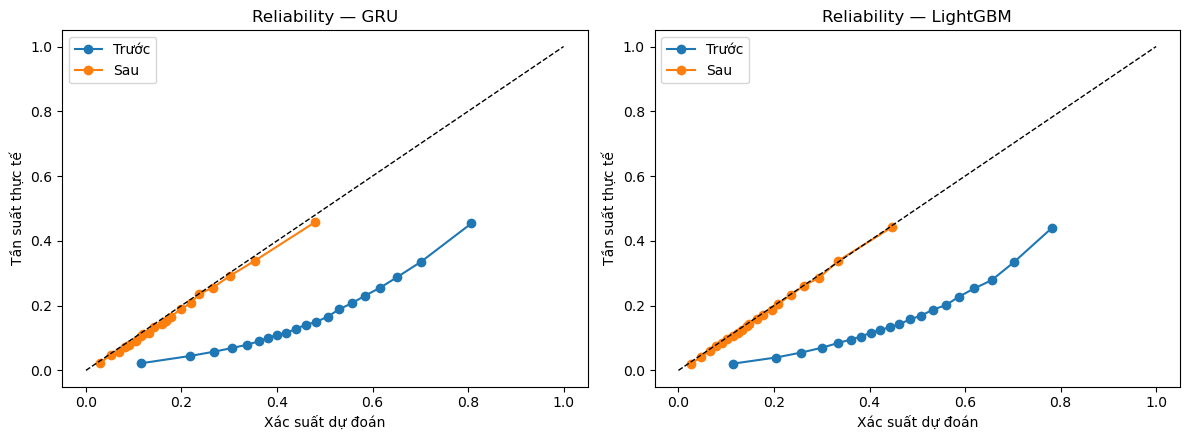

In [21]:
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def expected_calibration_error(y_true, p, n_bins=20):
    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    b = np.digitize(p, edges[1:-1])
    e = 0.0
    for k in range(n_bins):
        m = (b == k)
        if m.sum():
            e += m.mean() * abs(y_true[m].mean() - p[m].mean())
    return e

calibrators, p_cal = {}, {}
va_preds = {"GRU": gru["p_va"], "Logistic": p1_va, "LightGBM": p2_va}

rows_ = []
for name, pv in va_preds.items():
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1).fit(pv, yva)
    calibrators[name] = iso
    pc = iso.predict(preds[name])
    p_cal[name] = pc
    rows_.append({
        "model": name,
        "Brier_trước": brier_score_loss(yte, preds[name]),
        "Brier_sau":   brier_score_loss(yte, pc),
        "ECE_trước":   expected_calibration_error(yte, preds[name]),
        "ECE_sau":     expected_calibration_error(yte, pc),
        "mean_p_sau":  pc.mean(),
        "ROC_AUC_sau": roc_auc_score(yte, pc),
    })

print(f"Tỷ lệ dương thực tế trên test: {yte.mean():.4f}")
print(pd.DataFrame(rows_).round(4).to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for a, (name, pc) in zip([ax[0], ax[1]], [("GRU", p_cal["GRU"]),
                                          ("LightGBM", p_cal["LightGBM"])]):
    for p_, lab in [(preds[name], "Trước"), (pc, "Sau")]:
        fr, mp_ = calibration_curve(yte, p_, n_bins=20, strategy="quantile")
        a.plot(mp_, fr, "o-", label=lab)
    a.plot([0, 1], [0, 1], "k--", lw=1)
    a.set_title(f"Reliability — {name}")
    a.set_xlabel("Xác suất dự đoán"); a.set_ylabel("Tần suất thực tế")
    a.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/calibration.png", dpi=150); plt.show()

## Stage 8 — Kiểm định thống kê

In [22]:
from scipy import stats

def delong_auc_var(y_true, p):
    # Phương sai AUC theo DeLong (1988)
    pos, neg = p[y_true == 1], p[y_true == 0]
    m, n_ = len(pos), len(neg)
    def midrank(x):
        s = np.argsort(x); xs = x[s]
        r = np.zeros(len(x)); i = 0
        while i < len(xs):
            j = i
            while j < len(xs) - 1 and xs[j + 1] == xs[i]:
                j += 1
            r[s[i:j + 1]] = 0.5 * (i + j) + 1
            i = j + 1
        return r
    tx, ty, tz = midrank(pos), midrank(neg), midrank(p)
    auc = (tz[y_true == 1].sum() - m * (m + 1) / 2) / (m * n_)
    v01 = (tz[y_true == 1] - tx) / n_
    v10 = 1 - (tz[y_true == 0] - ty) / m
    return auc, v01.var(ddof=1) / m + v10.var(ddof=1) / n_

def delong_test(y_true, p1_, p2_):
    a1, s1 = delong_auc_var(y_true, p1_)
    a2, s2 = delong_auc_var(y_true, p2_)
    z = (a1 - a2) / np.sqrt(max(s1 + s2, 1e-12))
    return a1 - a2, 2 * (1 - stats.norm.cdf(abs(z)))

def boot_diff(y_true, p1_, p2_, fn=average_precision_score, n=None, seed=0):
    n = n or CONFIG["n_bootstrap"]
    rng = np.random.RandomState(seed)
    d_ = np.empty(n)
    for b in range(n):
        i = rng.randint(0, len(y_true), len(y_true))
        if y_true[i].sum() in (0, len(i)):
            d_[b] = np.nan; continue
        d_[b] = fn(y_true[i], p1_[i]) - fn(y_true[i], p2_[i])
    d_ = d_[~np.isnan(d_)]
    obs = fn(y_true, p1_) - fn(y_true, p2_)
    lo, hi = np.percentile(d_, [2.5, 97.5])
    return obs, lo, hi, 2 * min((d_ <= 0).mean(), (d_ >= 0).mean())

print("=== GRU vs BASELINE (tập test, xác suất đã hiệu chỉnh) ===\n")
for nm in ["LightGBM", "Logistic"]:
    dA, pA = delong_test(yte, p_cal["GRU"], p_cal[nm])
    dP, lo, hi, pP = boot_diff(yte, p_cal["GRU"], p_cal[nm])
    print(f"GRU vs {nm}")
    print(f"  ΔROC-AUC = {dA:+.4f}   DeLong p = {pA:.4f}")
    print(f"  ΔPR-AUC  = {dP:+.4f}   KTC95% [{lo:+.4f}, {hi:+.4f}]  p = {pP:.4f}")
    verdict = "KHÁC BIỆT có ý nghĩa" if min(pA, pP) < 0.05 else "TƯƠNG ĐƯƠNG (p>=0.05)"
    print(f"  -> {verdict}\n")

print("QUY TẮC VIẾT BÀI: nếu p >= 0.05, viết 'tương đương', "
      "TUYỆT ĐỐI không viết 'vượt trội'.")

=== GRU vs BASELINE (tập test, xác suất đã hiệu chỉnh) ===

GRU vs LightGBM
  ΔROC-AUC = +0.0055   DeLong p = 0.0000
  ΔPR-AUC  = +0.0060   KTC95% [+0.0044, +0.0075]  p = 0.0000
  -> KHÁC BIỆT có ý nghĩa

GRU vs Logistic
  ΔROC-AUC = +0.0627   DeLong p = 0.0000
  ΔPR-AUC  = +0.0656   KTC95% [+0.0641, +0.0671]  p = 0.0000
  -> KHÁC BIỆT có ý nghĩa

QUY TẮC VIẾT BÀI: nếu p >= 0.05, viết 'tương đương', TUYỆT ĐỐI không viết 'vượt trội'.


In [24]:
# =====================================================================
#  VÁ build_gru — sửa lỗi ablation "Bỏ nhánh chuỗi"
#  Chạy SAU cell Stage 6, TRƯỚC cell Stage 9.
#
#  Lỗi: ValueError: `inputs` not connected to `outputs`
#  Khi use_seq=False thì z = in_stat, nên in_ev và in_num không nối vào
#  graph -> Keras 3 từ chối dựng Functional model.
#  Sửa: nối chúng qua ZeroSink — đóng góp đúng 0.0 nên kết quả ablation
#  y hệt mô hình chỉ dùng đặc trưng tĩnh, mà graph vẫn hợp lệ.
# =====================================================================
class ZeroSink(keras.layers.Layer):
    """Nối tensor vào graph nhưng trả cột hằng 0 -> không ảnh hưởng đầu ra."""

    def call(self, x):
        v = ops.cast(x, "float32")
        axes = list(range(1, len(v.shape)))
        return ops.expand_dims(ops.sum(v, axis=axes) * 0.0, -1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], 1)


def build_gru(use_seq=True, pool_instead=False, use_cudnn_flag=None, **kw):
    c = {**CONFIG, **kw}
    gru_kw = {}
    flag = c.get("gru_use_cudnn", False) if use_cudnn_flag is None else use_cudnn_flag
    import inspect as _i
    if "use_cudnn" in _i.signature(layers.GRU.__init__).parameters:
        gru_kw["use_cudnn"] = flag

    in_ev   = keras.Input(shape=(MAX_LEN,), dtype="int32", name="ev")
    in_num  = keras.Input(shape=(MAX_LEN, N_NUM), dtype="float32", name="num")
    in_stat = keras.Input(shape=(N_STAT,), dtype="float32", name="stat")

    if use_seq:
        e = layers.Embedding(VOCAB, c["emb"], mask_zero=False, name="emb")(in_ev)
        x = layers.Concatenate(axis=-1)([e, in_num])
        seq_mask = SeqMask(name="seq_mask")(in_ev)
        if pool_instead:
            h = layers.GlobalAveragePooling1D()(x, mask=seq_mask)
            h = layers.Dense(c["units"], activation="relu")(h)
        else:
            h = layers.GRU(c["units"], name="gru_state", **gru_kw)(x, mask=seq_mask)
        z = layers.Concatenate(name="repr")([h, in_stat])
    else:
        # Ablation "bỏ nhánh chuỗi": vẫn phải nối in_ev / in_num vào graph.
        z = layers.Concatenate(name="repr")([
            in_stat,
            ZeroSink(name="sink_ev")(in_ev),
            ZeroSink(name="sink_num")(in_num),
        ])

    z = layers.Dense(c["dense"], activation="relu", name="repr_dense")(z)
    z = layers.Dropout(c["dropout"])(z)
    out = layers.Dense(1, activation="sigmoid", name="buy")(z)

    m = keras.Model({"ev": in_ev, "num": in_num, "stat": in_stat}, out)
    m.compile(optimizer=keras.optimizers.Adam(c["lr"]),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])
    return m


# --- Tự kiểm: cả 3 biến thể dựng được, và nhánh chuỗi thực sự bị vô hiệu ---
for _nm, _kw in [("đầy đủ", {}), ("mean-pool", dict(pool_instead=True)),
                 ("bỏ chuỗi", dict(use_seq=False))]:
    _m = build_gru(**_kw)
    print(f"  {_nm:12s} dựng OK | tham số: {_m.count_params():,}")

_i = select_idx("test", 256, 0)
_x = _slice(_i)
_m = build_gru(use_seq=False)
_p1 = _m.predict(_x, batch_size=256, verbose=0).ravel()
_x2 = {"ev": np.zeros_like(_x["ev"]),
       "num": np.random.rand(*_x["num"].shape).astype("float32"),
       "stat": _x["stat"]}
_p2 = _m.predict(_x2, batch_size=256, verbose=0).ravel()
print(f"  kiểm 'bỏ chuỗi': chênh lệch tối đa khi đổi chuỗi = {np.abs(_p1-_p2).max():.2e}"
      f" -> nhánh chuỗi bị vô hiệu hoàn toàn: {np.allclose(_p1, _p2, atol=1e-6)}")
del _m, _x, _x2, _p1, _p2, _i
print("Đã vá build_gru. Chạy lại cell Stage 9.")

  đầy đủ       dựng OK | tham số: 6,705
  mean-pool    dựng OK | tham số: 2,193
  bỏ chuỗi     dựng OK | tham số: 481
  kiểm 'bỏ chuỗi': chênh lệch tối đa khi đổi chuỗi = 0.00e+00 -> nhánh chuỗi bị vô hiệu hoàn toàn: True
Đã vá build_gru. Chạy lại cell Stage 9.


## Stage 9 — Ablation

Ba nhóm ablation trả lời ba câu hỏi mà phản biện chắc chắn sẽ đặt ra:

1. **Thứ tự sự kiện có mang thông tin không?** — xáo trộn thứ tự trong chuỗi.
   Nếu kết quả không đổi, `sequential modeling` không phải đóng góp và phải nói thật.
2. **Nhánh chuỗi có cần thiết không?** — bỏ hẳn chuỗi / thay GRU bằng mean-pooling.
3. **Từng nhóm đặc trưng đóng góp bao nhiêu?** — zero-hoá từng nhóm cột tĩnh.

In [27]:
# =====================================================================
#  STAGE 9 — ABLATION (có CHECKPOINT, ngắt giữa chừng vẫn chạy tiếp được)
# =====================================================================
import numpy as np, pandas as pd, gc, json, os, time

ABL_SEEDS  = [42, 43, 44]
ABL_EPOCHS = None          # ví dụ 20 để chạy nhanh hơn; None = giữ CONFIG["epochs"]
ABL_CACHE  = f"{OUT}/ablation_cache.json"


def _rowhash(rows, L, seed=0):
    u = np.uint64
    k = (rows.astype("uint64")[:, None] * u(0x9E3779B97F4A7C15)
         + np.arange(L, dtype="uint64")[None, :] * u(0xBF58476D1CE4E5B9)
         + u(seed))
    k ^= k >> u(30); k *= u(0xBF58476D1CE4E5B9)
    k ^= k >> u(27); k *= u(0x94D049BB133111EB)
    k ^= k >> u(31)
    return (k >> u(11)).astype("float64") / float(1 << 53)


def _shuffle_steps(ev_, num_, rows):
    r = np.where(ev_ == 0, 2.0, _rowhash(np.asarray(rows), ev_.shape[1]))
    order = np.argsort(r, axis=1, kind="stable")
    return (np.take_along_axis(ev_, order, axis=1),
            np.take_along_axis(num_, order[:, :, None], axis=1))


def _slice(j, shuffle_seq=False, seed=0):
    j = np.asarray(j)
    ev_  = X_ev[j].astype("int32")
    num_ = np.asarray(X_num[j], dtype="float32")
    ev_, num_ = _right_pack(ev_, num_)
    if shuffle_seq:
        ev_, num_ = _shuffle_steps(ev_, num_, j)
    return {"ev": ev_, "num": num_,
            "stat": np.asarray(X_stat[j], dtype="float32")}


def _load_cache():
    if os.path.exists(ABL_CACHE):
        try:
            with open(ABL_CACHE, encoding="utf-8") as f:
                return json.load(f)
        except json.JSONDecodeError:
            print("  cache hỏng -> bỏ qua, chạy lại từ đầu")
    return {}


def _save_cache(c):
    tmp = ABL_CACHE + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(c, f, ensure_ascii=False, indent=1)
    os.replace(tmp, ABL_CACHE)      # ghi nguyên tử: ngắt giữa chừng không hỏng file


def run_ablation(name, drop_cols=None, seeds=None, **kw):
    seeds = seeds or ABL_SEEDS
    cache = _load_cache()
    todo  = [s for s in seeds if f"{name}|{s}" not in cache]

    if not todo:
        print(f"  {name:24s} [đã có sẵn trong checkpoint, bỏ qua]")
    else:
        if len(todo) < len(seeds):
            print(f"  {name:24s} còn thiếu seed {todo}")
        backup, old_ep = None, CONFIG["epochs"]
        if drop_cols:
            backup = X_stat[:, drop_cols].copy()
            X_stat[:, drop_cols] = 0.0
        if ABL_EPOCHS:
            CONFIG["epochs"] = ABL_EPOCHS
        try:
            for s in todo:
                t0 = time.time()
                out = run_gru(seed=s, verbose=0, **kw)
                cache = _load_cache()
                cache[f"{name}|{s}"] = {k: float(v) for k, v in out["res"].items()}
                _save_cache(cache)
                print(f"    ✓ lưu checkpoint: {name} seed {s} ({time.time()-t0:.0f}s)")
                del out; gc.collect()
        finally:
            CONFIG["epochs"] = old_ep
            if backup is not None:
                X_stat[:, drop_cols] = backup

    df = pd.DataFrame([cache[f"{name}|{s}"] for s in seeds if f"{name}|{s}" in cache])
    r = {c: df[c].mean() for c in df.columns}
    r.update({f"{c}_std": (df[c].std(ddof=1) if len(df) > 1 else 0.0)
              for c in ["PR-AUC", "ROC-AUC"]})
    r["n_seeds"] = len(df)
    print(f"  {name:24s} PR-AUC={r['PR-AUC']:.4f}±{r['PR-AUC_std']:.4f}  "
          f"ROC-AUC={r['ROC-AUC']:.4f}±{r['ROC-AUC_std']:.4f}  (n={len(df)})")
    return r


CAL_COLS   = [ALL_STAT.index(c) for c in ["dow", "hour", "woy"]]
TREAT_COLS = [ALL_STAT.index(c) for c in TREAT]
PRICE_COLS = [ALL_STAT.index(c) for c in ["log_ref", "cv", "days_since_chg"]]
USER_COLS  = [ALL_STAT.index(c) for c in ["u_rm", "u_bu"]]

PLAN = [
    ("Full",               dict()),
    ("Xáo trộn thứ tự",    dict(shuffle_seq=True)),
    ("Bỏ nhánh chuỗi",     dict(use_seq=False)),
    ("Mean-pool thay GRU", dict(pool_instead=True)),
    ("− treatment",        dict(drop_cols=TREAT_COLS)),
    ("− lịch",             dict(drop_cols=CAL_COLS)),
    ("− giá",              dict(drop_cols=PRICE_COLS)),
    ("− lịch sử user",     dict(drop_cols=USER_COLS)),
]

_c = _load_cache()
_done = sum(1 for n, _ in PLAN for s in ABL_SEEDS if f"{n}|{s}" in _c)
_total = len(PLAN) * len(ABL_SEEDS)
print(f"Checkpoint: {ABL_CACHE}")
print(f"Đã xong {_done}/{_total} lần chạy, còn lại {_total - _done}.")
print(f"Ước tính thời gian còn lại: ~{(_total - _done) * 5} phút\n")

abl = {}
for _name, _kw in PLAN:
    abl[_name] = run_ablation(_name, **_kw)

cols = [c for c in ["PR-AUC", "PR-AUC_std", "ROC-AUC", "ROC-AUC_std", "Brier"]
        if c in pd.DataFrame(abl).T.columns]
tab = pd.DataFrame(abl).T[cols + ["n_seeds"]]
full_mu, full_sd = tab.loc["Full", "PR-AUC"], tab.loc["Full", "PR-AUC_std"]
tab["Δ PR-AUC"] = tab["PR-AUC"] - full_mu
tab["Δ %"] = (tab["Δ PR-AUC"] / full_mu * 100).round(1)

noise = 1.96 * np.sqrt(full_sd**2 + tab["PR-AUC_std"]**2) / np.sqrt(len(ABL_SEEDS))
tab["Có ý nghĩa?"] = np.where(tab.index == "Full", "—",
                     np.where(tab["Δ PR-AUC"].abs() > noise, "CÓ", "không"))

print(f"\n=== BẢNG ABLATION (mean ± std trên {len(ABL_SEEDS)} seed) ===")
print(tab.round(4).to_string())
tab.to_csv(f"{OUT}/ablation.csv")

if {"Full", "Bỏ nhánh chuỗi", "Xáo trộn thứ tự"} <= set(tab.index):
    seq_gain   = tab.loc["Full", "PR-AUC"] - tab.loc["Bỏ nhánh chuỗi", "PR-AUC"]
    order_gain = tab.loc["Full", "PR-AUC"] - tab.loc["Xáo trộn thứ tự", "PR-AUC"]
    print("\n--- Phân rã đóng góp của nhánh chuỗi ---")
    print(f"  Toàn bộ nhánh chuỗi : +{seq_gain:.4f} PR-AUC")
    print(f"  Riêng THỨ TỰ        : +{order_gain:.4f} PR-AUC "
          f"({order_gain/max(seq_gain,1e-9)*100:.1f}% của nhánh chuỗi)")
    print(f"  Còn lại là NỘI DUNG : +{seq_gain-order_gain:.4f} PR-AUC "
          f"({(seq_gain-order_gain)/max(seq_gain,1e-9)*100:.1f}%)")

print("\nChỉ diễn giải các dòng có 'Có ý nghĩa?' = CÓ. "
      f"Xoá {ABL_CACHE} nếu muốn chạy lại toàn bộ.")

Checkpoint: ./ablation_cache.json
Đã xong 0/24 lần chạy, còn lại 24.
Ước tính thời gian còn lại: ~120 phút

    val PR-AUC = 0.3047
    val PR-AUC = 0.3103
    val PR-AUC = 0.3132
    val PR-AUC = 0.3169
    val PR-AUC = 0.3186
    val PR-AUC = 0.3189
    val PR-AUC = 0.3221
    val PR-AUC = 0.3227
    val PR-AUC = 0.3223
    val PR-AUC = 0.3241
    val PR-AUC = 0.3234
    val PR-AUC = 0.3236
    val PR-AUC = 0.3251
    val PR-AUC = 0.3251
    val PR-AUC = 0.3250
    val PR-AUC = 0.3260
    val PR-AUC = 0.3269
    val PR-AUC = 0.3255
    val PR-AUC = 0.3255
    val PR-AUC = 0.3268
  seed 42 | 365s | batch=4096 | PR-AUC=0.3277 ROC-AUC=0.7116
    ✓ lưu checkpoint: Full seed 42 (366s)
    val PR-AUC = 0.3038
    val PR-AUC = 0.3103
    val PR-AUC = 0.3153
    val PR-AUC = 0.3182
    val PR-AUC = 0.3188
    val PR-AUC = 0.3197
    val PR-AUC = 0.3203
    val PR-AUC = 0.3220
    val PR-AUC = 0.3213
    val PR-AUC = 0.3227
    val PR-AUC = 0.3228
    val PR-AUC = 0.3229
    val PR-AUC = 0.32

## Stage 10 — Tầng nhân quả: propensity, overlap, uplift

Đây là phần được **viết lại hoàn toàn** so với bản `Uplift_Promotion_Pipeline`.

Trình tự bắt buộc, không được bỏ bước nào:

1. **Ước lượng propensity** e(x) = P(T=1 | X) **chỉ từ hiệp biến INVAR**, tuyệt đối
   không dùng cột treatment.
2. **Kiểm tra overlap.** Nếu e(x) tách đôi hoàn toàn theo T thì positivity bị vi phạm
   và mọi ước lượng CATE phía sau đều vô nghĩa — đây chính là lỗi của bản cũ khi để
   `price_deviation` nằm trong X.
3. **Trimming** về vùng chồng lấn.
4. **T-learner** trên vùng đã trim, dùng biểu diễn GRU đã huấn luyện làm đặc trưng.

In [28]:
# --- 1. Propensity model: CHỈ dùng INVAR ---
INVAR_COLS = [ALL_STAT.index(c) for c in INVAR]
T_all = dp["treated"].values.astype(int)

Ztr = X_stat[itr][:, INVAR_COLS]
Zva = X_stat[iva][:, INVAR_COLS]
Zte = X_stat[ite][:, INVAR_COLS]
Ttr, Tva, Tte = T_all[itr], T_all[iva], T_all[ite]

ps_model = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05,
                              num_leaves=31, random_state=42, verbose=-1)
ps_model.fit(Ztr, Ttr, eval_set=[(Zva, Tva)],
             callbacks=[lgb.early_stopping(50, verbose=False)])

e_te = np.clip(ps_model.predict_proba(Zte)[:, 1], 1e-6, 1 - 1e-6)
e_tr = np.clip(ps_model.predict_proba(Ztr)[:, 1], 1e-6, 1 - 1e-6)

print(f"AUC của propensity model: {roc_auc_score(Tte, e_te):.4f}")
print("  ~0.5  -> treatment gần như ngẫu nhiên (tốt cho suy luận nhân quả)")
print("  >0.9  -> treatment gần như xác định bởi X (positivity bị đe doạ)")

/opt/conda/lib/python3.11/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


AUC của propensity model: 0.9876
  ~0.5  -> treatment gần như ngẫu nhiên (tốt cho suy luận nhân quả)
  >0.9  -> treatment gần như xác định bởi X (positivity bị đe doạ)


   nhóm    min    p05  median   p95    max
Control 0.0000 0.0000  0.0000 0.000 0.9568
Treated 0.0011 0.0174  0.4009 0.793 0.9381

Trimming e(x) vào [0.05, 0.95]:
  train giữ 6.9% | test giữ 3.6%
  CẢNH BÁO NẶNG: mất quá nửa mẫu -> overlap kém, ước lượng nhân quả KHÔNG đáng tin. Xem lại định nghĩa treatment.


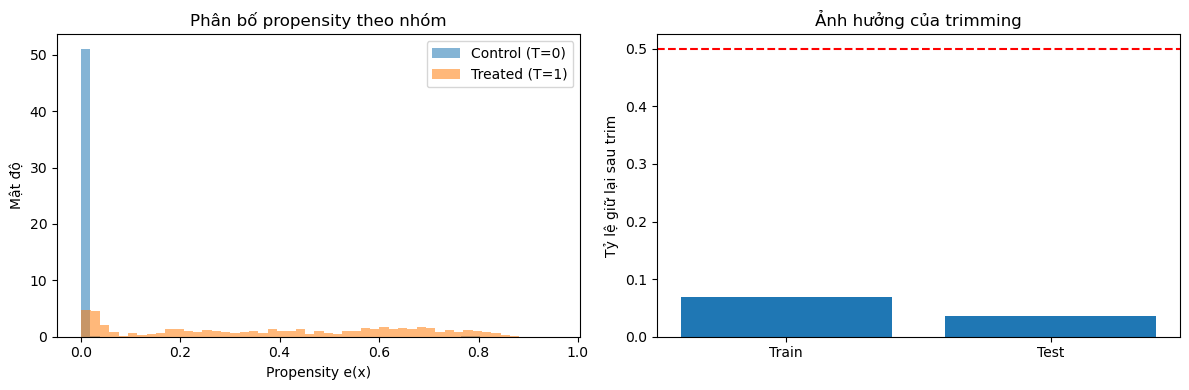

In [29]:
# --- 2. Chẩn đoán overlap ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for t_, lab in [(0, "Control (T=0)"), (1, "Treated (T=1)")]:
    ax[0].hist(e_te[Tte == t_], bins=50, alpha=0.55, density=True, label=lab)
ax[0].set_xlabel("Propensity e(x)"); ax[0].set_ylabel("Mật độ")
ax[0].set_title("Phân bố propensity theo nhóm"); ax[0].legend()

ov = pd.DataFrame({
    "nhóm": ["Control", "Treated"],
    "min":  [e_te[Tte == 0].min(),  e_te[Tte == 1].min()],
    "p05":  [np.quantile(e_te[Tte == 0], .05), np.quantile(e_te[Tte == 1], .05)],
    "median": [np.median(e_te[Tte == 0]), np.median(e_te[Tte == 1])],
    "p95":  [np.quantile(e_te[Tte == 0], .95), np.quantile(e_te[Tte == 1], .95)],
    "max":  [e_te[Tte == 0].max(),  e_te[Tte == 1].max()],
})
print(ov.round(4).to_string(index=False))

LO, HI = 0.05, 0.95
keep_tr = (e_tr > LO) & (e_tr < HI)
keep_te = (e_te > LO) & (e_te < HI)
print(f"\nTrimming e(x) vào [{LO}, {HI}]:")
print(f"  train giữ {keep_tr.mean():.1%} | test giữ {keep_te.mean():.1%}")
if keep_te.mean() < 0.5:
    print("  CẢNH BÁO NẶNG: mất quá nửa mẫu -> overlap kém, "
          "ước lượng nhân quả KHÔNG đáng tin. Xem lại định nghĩa treatment.")

ax[1].bar(["Train", "Test"], [keep_tr.mean(), keep_te.mean()])
ax[1].axhline(0.5, ls="--", c="r"); ax[1].set_ylabel("Tỷ lệ giữ lại sau trim")
ax[1].set_title("Ảnh hưởng của trimming")
plt.tight_layout(); plt.savefig(f"{OUT}/overlap.png", dpi=150); plt.show()

In [30]:
# --- 3. Biểu diễn GRU ĐÃ HUẤN LUYỆN làm đặc trưng cho CATE ---
repr_model = keras.Model(gru["model"].input,
                         gru["model"].get_layer("repr_dense").output)

def embed(i, batch=None):
    """Trích embedding theo lô. Dùng _slice để ép int32 + bảo hiểm right-padding."""
    batch = batch or PREDICT_BS
    outs = []
    for s in range(0, len(i), batch):
        outs.append(repr_model.predict(_slice(i[s:s + batch]),
                                       batch_size=batch, verbose=0))
    return np.vstack(outs)

Etr = np.hstack([embed(itr), X_stat[itr][:, INVAR_COLS]])
Ete = np.hstack([embed(ite), X_stat[ite][:, INVAR_COLS]])
Eva = np.hstack([embed(iva), X_stat[iva][:, INVAR_COLS]])
print(f"Đặc trưng CATE: {Etr.shape}")
assert Etr.shape[1] == Ete.shape[1]

Đặc trưng CATE: (3929933, 41)


In [31]:
# --- 4. T-learner trên vùng đã trim ---
def fit_t_learner(E, T, Y, keep, seed=42):
    m1 = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                            min_child_samples=50, random_state=seed, verbose=-1)
    m0 = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                            min_child_samples=50, random_state=seed, verbose=-1)
    a, b = keep & (T == 1), keep & (T == 0)
    print(f"  n(treated)={a.sum():,}  n(control)={b.sum():,}")
    m1.fit(E[a], Y[a]); m0.fit(E[b], Y[b])
    return m1, m0

ytr_, yte_ = y[itr], y[ite]
m1, m0 = fit_t_learner(Etr, Ttr, ytr_, keep_tr)

mu1_te = m1.predict_proba(Ete)[:, 1]
mu0_te = m0.predict_proba(Ete)[:, 1]
tau_te = mu1_te - mu0_te

print("\nPhân bố τ̂ trên test (chỉ vùng overlap):")
print(pd.Series(tau_te[keep_te]).describe().round(4).to_string())
print(f"\nTỷ lệ τ̂ > 0: {(tau_te[keep_te] > 0).mean():.1%}")
print("Nếu τ̂ tập trung quanh 0 -> khuyến mãi ít tác dụng biên; "
      "đó là một PHÁT HIỆN, không phải thất bại.")

  n(treated)=176,642  n(control)=95,826

Phân bố τ̂ trên test (chỉ vùng overlap):
count    28908.0000
mean        -0.0394
std          0.0772
min         -0.7874
25%         -0.0710
50%         -0.0328
75%         -0.0022
max          0.4606

Tỷ lệ τ̂ > 0: 23.0%
Nếu τ̂ tập trung quanh 0 -> khuyến mãi ít tác dụng biên; đó là một PHÁT HIỆN, không phải thất bại.


## Stage 11 — Qini / AUUC và đánh giá chính sách

`uplift_curve` của bản cũ chỉ tính hiệu số tỷ lệ thô ở top-k, không phải Qini.
Ở đây dùng đúng định nghĩa:

$$\text{Qini}(k) = Y_T(k) - Y_C(k)\cdot\frac{N_T(k)}{N_C(k)}$$

và so với đường ngẫu nhiên. Ngoài ra đánh giá **giá trị chính sách** bằng IPW —
đây mới là con số trả lời "nếu áp dụng quy tắc này thì được gì".

Chiến lược xếp hạng            AUUC
T-learner (τ̂)               0.2905
Propensity (p̂ buy)         -0.1274
Ngẫu nhiên                  -0.0085


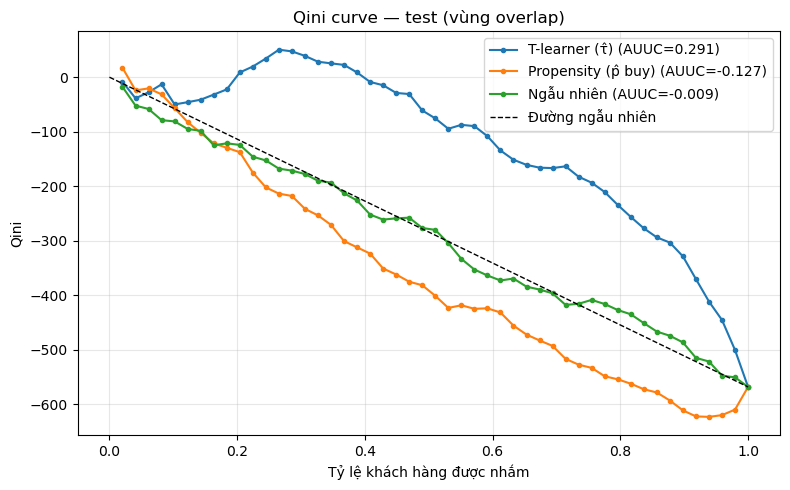


So sánh mấu chốt của bài: nếu xếp hạng theo propensity KHÔNG tốt hơn
ngẫu nhiên, đó là bằng chứng thực nghiệm cho luận điểm 'targeting theo
propensity bị đảo ngược' (Ascarza 2018) — hãy đưa hình này vào bài.


In [32]:
def qini_curve(y_true, T, score, n_pts=50):
    o = np.argsort(-score)
    y_, t_ = y_true[o], T[o]
    n = len(y_)
    ks = np.unique(np.linspace(1, n, n_pts).astype(int))
    rows_ = []
    for k in ks:
        yt, tt = y_[:k], t_[:k]
        nt, nc = tt.sum(), (1 - tt).sum()
        if nt == 0 or nc == 0:
            continue
        q = yt[tt == 1].sum() - yt[tt == 0].sum() * nt / nc
        rows_.append({"k": k, "frac": k / n, "qini": q})
    return pd.DataFrame(rows_)

def auuc_score(qdf, n_total):
    # Diện tích giữa đường Qini và đường ngẫu nhiên, chuẩn hoá
    if len(qdf) < 2:
        return np.nan
    x, q = qdf["frac"].values, qdf["qini"].values
    rand = q[-1] * x
    _trap = getattr(np, "trapezoid", None) or np.trapz   # numpy>=2 đổi tên
    return _trap(q - rand, x) / max(abs(q[-1]), 1e-9)

ykeep, Tkeep = yte_[keep_te], Tte[keep_te]
curves = {
    "T-learner (τ̂)":     tau_te[keep_te],
    "Propensity (p̂ buy)": p_cal["GRU"][keep_te],
    "Ngẫu nhiên":         np.random.RandomState(0).rand(keep_te.sum()),
}

plt.figure(figsize=(8, 5))
print(f"{'Chiến lược xếp hạng':24s} {'AUUC':>10s}")
for nm, sc_ in curves.items():
    qd = qini_curve(ykeep, Tkeep, sc_)
    a = auuc_score(qd, len(ykeep))
    print(f"{nm:24s} {a:>10.4f}")
    plt.plot(qd["frac"], qd["qini"], marker="o", ms=3, label=f"{nm} (AUUC={a:.3f})")

qd0 = qini_curve(ykeep, Tkeep, curves["T-learner (τ̂)"])
plt.plot([0, 1], [0, qd0["qini"].values[-1]], "k--", lw=1, label="Đường ngẫu nhiên")
plt.xlabel("Tỷ lệ khách hàng được nhắm"); plt.ylabel("Qini")
plt.title("Qini curve — test (vùng overlap)"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{OUT}/qini.png", dpi=150); plt.show()

print("\nSo sánh mấu chốt của bài: nếu xếp hạng theo propensity KHÔNG tốt hơn")
print("ngẫu nhiên, đó là bằng chứng thực nghiệm cho luận điểm 'targeting theo")
print("propensity bị đảo ngược' (Ascarza 2018) — hãy đưa hình này vào bài.")

In [33]:
# --- Giá trị chính sách bằng IPW ---
def policy_value_ipw(y_true, T, e, pi):
    # pi: 1 nếu chính sách quyết định treat. Ước lượng E[Y(pi)] bằng IPW.
    w = np.where(pi == 1, 1.0 / e, 1.0 / (1 - e))
    m = (T == pi)
    return float((y_true[m] * w[m]).sum() / w[m].sum())

ek = e_te[keep_te]
policies = {
    "Không ai được KM":        np.zeros(len(ykeep), dtype=int),
    "Tất cả được KM":          np.ones(len(ykeep), dtype=int),
    "Theo τ̂ > 0":              (tau_te[keep_te] > 0).astype(int),
    "Top 10% theo τ̂":          (tau_te[keep_te] >=
                                np.quantile(tau_te[keep_te], 0.90)).astype(int),
    "Top 10% theo propensity": (p_cal["GRU"][keep_te] >=
                                np.quantile(p_cal["GRU"][keep_te], 0.90)).astype(int),
}

pv = []
for nm, pi in policies.items():
    pv.append({"chính sách": nm,
               "tỷ lệ được KM": pi.mean(),
               "giá trị (E[Y])": policy_value_ipw(ykeep, Tkeep, ek, pi)})
pvdf = pd.DataFrame(pv)
base = pvdf.loc[pvdf["chính sách"] == "Không ai được KM", "giá trị (E[Y])"].values[0]
pvdf["Δ so với không KM"] = pvdf["giá trị (E[Y])"] - base
print("=== GIÁ TRỊ CHÍNH SÁCH (IPW) ===")
print(pvdf.round(4).to_string(index=False))
print("\nLƯU Ý: IPW chỉ đúng dưới giả định unconfoundedness. Với treatment proxy")
print("từ biến động giá, phải nêu rõ đây là giả định KHÔNG kiểm chứng được.")

=== GIÁ TRỊ CHÍNH SÁCH (IPW) ===
             chính sách  tỷ lệ được KM  giá trị (E[Y])  Δ so với không KM
       Không ai được KM         0.0000          0.1771             0.0000
         Tất cả được KM         1.0000          0.1560            -0.0210
            Theo τ̂ > 0         0.2297          0.1859             0.0088
        Top 10% theo τ̂         0.1000          0.1873             0.0102
Top 10% theo propensity         0.1013          0.1945             0.0174

LƯU Ý: IPW chỉ đúng dưới giả định unconfoundedness. Với treatment proxy
từ biến động giá, phải nêu rõ đây là giả định KHÔNG kiểm chứng được.


## Stage 12 — Chính sách mức giảm giá và lợi nhuận kỳ vọng

Sửa lỗi cốt lõi của bản cũ: ở đó `profit = τ̂ × price × (1−d)` với `τ̂` **không phụ
thuộc `d`**, nên nghiệm tối ưu luôn là `d = 0` do chính cấu trúc công thức, chứ
không phải do dữ liệu.

Bản này:

* ước lượng τ̂ **riêng cho từng mức `d`** trong lưới các mức **quan sát được**;
* tính trên **biên lợi nhuận**, không phải doanh thu:
  $$\Delta\text{Profit}(d) = \hat\tau(x, d)\cdot P\cdot(m - d)$$
  với `m` là biên gộp khi không giảm giá — chi phí khuyến mãi được trừ đúng cách.

In [34]:
D_GRID = CONFIG["d_grid"]
MARGIN = CONFIG["margin_rate"]
price_te = dp["price_raw"].values[ite]

# τ̂ theo từng mức d: so nhóm có d trong dải với nhóm control (d=0)
d_all = dp["d"].values
d_tr, d_te = d_all[itr], d_all[ite]

def band(dv, center, half=0.035):
    return (dv >= center - half) & (dv <= center + half) if center > 0 else (dv < 0.01)

tau_by_d, support = {}, {}
ctrl_tr = keep_tr & band(d_tr, 0.0)
m0_d = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                          min_child_samples=50, random_state=42, verbose=-1)
m0_d.fit(Etr[ctrl_tr], ytr_[ctrl_tr])
mu0_d = m0_d.predict_proba(Ete)[:, 1]

for dv in D_GRID:
    if dv == 0:
        tau_by_d[dv] = np.zeros(len(Ete)); support[dv] = int(ctrl_tr.sum()); continue
    m_ = keep_tr & band(d_tr, dv)
    support[dv] = int(m_.sum())
    if m_.sum() < 500:
        tau_by_d[dv] = np.full(len(Ete), np.nan)
        print(f"  d={dv:.3f}: chỉ {m_.sum():,} mẫu -> BỎ QUA (không đủ hỗ trợ)")
        continue
    m1_d = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                              min_child_samples=50, random_state=42, verbose=-1)
    m1_d.fit(Etr[m_], ytr_[m_])
    tau_by_d[dv] = m1_d.predict_proba(Ete)[:, 1] - mu0_d
    print(f"  d={dv:.3f}: n_train={m_.sum():,}  τ̂ trung bình={np.nanmean(tau_by_d[dv]):+.4f}")

  d=0.075: n_train=130,671  τ̂ trung bình=-0.0376
  d=0.125: n_train=79,958  τ̂ trung bình=-0.0282
  d=0.175: n_train=25,771  τ̂ trung bình=-0.0210
  d=0.250: n_train=6,397  τ̂ trung bình=-0.0237


In [35]:
# --- Lợi nhuận biên kỳ vọng tăng thêm theo từng mức d ---
rows_ = []
profit_mat = np.full((len(Ete), len(D_GRID)), np.nan)
for j, dv in enumerate(D_GRID):
    t_ = tau_by_d[dv]
    if np.all(np.isnan(t_)):
        continue
    delta_profit = t_ * price_te * (MARGIN - dv)   # trừ đúng chi phí khuyến mãi
    profit_mat[:, j] = delta_profit
    rows_.append({
        "d": dv, "d_%": f"{dv*100:.1f}%", "n_train_support": support[dv],
        "τ̂_trung_bình": np.nanmean(t_),
        "Δprofit_trung_bình": np.nanmean(delta_profit[keep_te]),
        "tỷ_lệ_Δprofit>0": np.nanmean(delta_profit[keep_te] > 0),
    })

sim = pd.DataFrame(rows_)
print("=== MÔ PHỎNG MỨC GIẢM GIÁ (chỉ các mức có đủ hỗ trợ dữ liệu) ===")
print(sim.round(4).to_string(index=False))

valid = [j for j, dv in enumerate(D_GRID) if not np.all(np.isnan(profit_mat[:, j]))]
best_j = np.nanargmax(np.where(np.isnan(profit_mat[:, valid]), -np.inf,
                               profit_mat[:, valid]), axis=1)
best_d = np.array([D_GRID[valid[j]] for j in best_j])
gain = np.nanmax(profit_mat[:, valid], axis=1)
best_d[gain <= 0] = 0.0     # không có mức nào sinh lời -> không khuyến mãi

print("\n=== CHÍNH SÁCH d* THEO TỪNG DECISION POINT (vùng overlap) ===")
print(pd.Series(best_d[keep_te]).value_counts(normalize=True)
        .sort_index().round(4).to_string())
print(f"\nΔprofit trung bình của chính sách d*: "
      f"{np.nanmean(np.maximum(gain[keep_te], 0)):.4f} đơn vị tiền/decision point")
print(f"Biên lợi nhuận giả định m = {MARGIN:.0%} — hãy kiểm định độ nhạy "
      f"với m = 20% và 40% trước khi đưa vào bài.")

=== MÔ PHỎNG MỨC GIẢM GIÁ (chỉ các mức có đủ hỗ trợ dữ liệu) ===
    d   d_%  n_train_support  τ̂_trung_bình  Δprofit_trung_bình  tỷ_lệ_Δprofit>0
0.000  0.0%            61916         0.0000              0.0000           0.0000
0.075  7.5%           130671        -0.0376             -0.0717           0.2304
0.125 12.5%            79958        -0.0282             -0.0563           0.2235
0.175 17.5%            25771        -0.0210             -0.0312           0.2243
0.250 25.0%             6397        -0.0237             -0.0162           0.2616

=== CHÍNH SÁCH d* THEO TỪNG DECISION POINT (vùng overlap) ===
0.000    0.4854
0.075    0.1279
0.125    0.1089
0.175    0.1227
0.250    0.1552

Δprofit trung bình của chính sách d*: 0.0357 đơn vị tiền/decision point
Biên lợi nhuận giả định m = 30% — hãy kiểm định độ nhạy với m = 20% và 40% trước khi đưa vào bài.


## Stage 13 — Đa seed và bảng kết quả cuối

In [36]:
# Đa seed: tận dụng checkpoint của Stage 9 (Full|seed) để khỏi chạy lại
cache = _load_cache()
multi = []
for s in CONFIG["seeds"]:
    key = f"Full|{s}"
    if key in cache:
        print(f"--- seed {s}: lấy từ checkpoint ---")
        multi.append({"seed": s, **cache[key]})
        continue
    print(f"\n--- seed {s}: huấn luyện mới ---")
    o = run_gru(seed=s, verbose=0)
    multi.append({"seed": s, **o["res"]})
    cache = _load_cache(); cache[key] = {k: float(v) for k, v in o["res"].items()}
    _save_cache(cache)
    del o; gc.collect()

mdf = pd.DataFrame(multi).set_index("seed")
print("\n=== GRU QUA NHIỀU SEED ===")
print(mdf.round(4).to_string())
print("\nmean ± std:")
for c in mdf.columns:
    print(f"  {c:12s} {mdf[c].mean():.4f} ± {mdf[c].std():.4f}")

--- seed 42: lấy từ checkpoint ---
--- seed 43: lấy từ checkpoint ---
--- seed 44: lấy từ checkpoint ---

--- seed 45: huấn luyện mới ---
    val PR-AUC = 0.3021
    val PR-AUC = 0.3117
    val PR-AUC = 0.3165
    val PR-AUC = 0.3192
    val PR-AUC = 0.3204
    val PR-AUC = 0.3226
    val PR-AUC = 0.3227
    val PR-AUC = 0.3238
    val PR-AUC = 0.3238
    val PR-AUC = 0.3238
    val PR-AUC = 0.3241
    val PR-AUC = 0.3256
    val PR-AUC = 0.3249
    val PR-AUC = 0.3259
    val PR-AUC = 0.3260
    val PR-AUC = 0.3261
    val PR-AUC = 0.3240
    val PR-AUC = 0.3261
    val PR-AUC = 0.3260
    val PR-AUC = 0.3250
    val PR-AUC = 0.3270
    val PR-AUC = 0.3267
    val PR-AUC = 0.3265
    val PR-AUC = 0.3257
  seed 45 | 429s | batch=4096 | PR-AUC=0.3291 ROC-AUC=0.7127

--- seed 46: huấn luyện mới ---
    val PR-AUC = 0.3022
    val PR-AUC = 0.3090
    val PR-AUC = 0.3151
    val PR-AUC = 0.3173
    val PR-AUC = 0.3180
    val PR-AUC = 0.3206
    val PR-AUC = 0.3208
    val PR-AUC = 0.3215


In [37]:
# --- Bảng tổng hợp để dán thẳng vào bài báo ---
final = pd.DataFrame({
    m: evaluate(yte, p_cal.get(m, preds[m])) for m in
    ["Majority", "Logistic", "LightGBM", "GRU"]
}).T
final["Brier"] = [brier_score_loss(yte, p_cal.get(m, preds[m]))
                  for m in final.index]

dA, pA = delong_test(yte, p_cal["GRU"], p_cal["LightGBM"])
dP, lo, hi, pP = boot_diff(yte, p_cal["GRU"], p_cal["LightGBM"])

print("=== BẢNG KẾT QUẢ CUỐI (test, xác suất đã hiệu chỉnh) ===")
print(final.round(4).to_string())
print(f"\nGRU vs LightGBM: ΔROC-AUC={dA:+.4f} (DeLong p={pA:.4f}) | "
      f"ΔPR-AUC={dP:+.4f} KTC95%[{lo:+.4f},{hi:+.4f}] (p={pP:.4f})")
print(f"n_test={len(yte):,} | tỷ lệ dương={yte.mean():.2%} | "
      f"seeds={CONFIG['seeds']} | split={CONFIG['split_mode']}")

final.to_csv(f"{OUT}/final_results.csv")
tab.to_csv(f"{OUT}/ablation.csv")
sim.to_csv(f"{OUT}/discount_simulation.csv", index=False)
pvdf.to_csv(f"{OUT}/policy_value.csv", index=False)
mdf.to_csv(f"{OUT}/multi_seed.csv")
print(f"\nĐã xuất CSV vào {OUT}.")

=== BẢNG KẾT QUẢ CUỐI (test, xác suất đã hiệu chỉnh) ===
          PR-AUC  ROC-AUC   Brier    P@5%  Lift@5%   P@10%  Lift@10%   P@20%  Lift@20%
Majority  0.1617   0.5000  0.1357  0.1533   0.9484  0.1591    0.9841  0.1626    1.0060
Logistic  0.2584   0.6481  0.1306  0.3531   2.1839  0.3199    1.9789  0.2784    1.7220
LightGBM  0.3180   0.7052  0.1248  0.4394   2.7181  0.3864    2.3903  0.3264    2.0186
GRU       0.3239   0.7108  0.1243  0.4540   2.8082  0.3944    2.4394  0.3333    2.0617

GRU vs LightGBM: ΔROC-AUC=+0.0055 (DeLong p=0.0000) | ΔPR-AUC=+0.0060 KTC95%[+0.0044,+0.0075] (p=0.0000)
n_test=806,757 | tỷ lệ dương=16.17% | seeds=[42, 43, 44, 45, 46] | split=chronological

Đã xuất CSV vào ..


In [38]:
# =====================================================================
#  XUẤT KẾT QUẢ — gói mọi thứ vào 1 file .md + 1 file .zip để chia sẻ
# =====================================================================
import os, glob, json, zipfile, datetime
import numpy as np, pandas as pd

if os.path.isdir("/kaggle/working"):
    DL, ENV = "/kaggle/working", "Kaggle"
elif os.path.isdir("/content"):
    DL, ENV = "/content", "Colab"
else:
    DL, ENV = ".", "khác"
print(f"Môi trường: {ENV} | thư mục tải về: {DL} | OUT = {OUT}")

CSVS = ["final_results.csv", "ablation.csv", "multi_seed.csv",
        "discount_simulation.csv", "policy_value.csv"]
PNGS = ["calibration.png", "overlap.png", "qini.png"]

L = []
def w(s=""):
    L.append(str(s))

w("# Kết quả Promotion Pipeline v2")
w(f"_Xuất lúc {datetime.datetime.now():%Y-%m-%d %H:%M} — môi trường {ENV}_")
w()

w("## 1. Cấu hình")
w("```")
for k in ["split_mode", "max_len", "window_days", "outcome_window_minutes",
          "treat_threshold", "ref_window_days", "units", "emb", "batch_size",
          "epochs", "margin_rate", "subsample", "seeds"]:
    if k in CONFIG:
        w(f"{k:24s} {CONFIG[k]}")
w("```")
w()

w("## 2. Quy mô dữ liệu")
try:
    w("| split | n | tỷ lệ y=1 | tỷ lệ treated |")
    w("|---|---:|---:|---:|")
    for s in ["train", "val", "test"]:
        m = (dp["split"] == s).values
        w(f"| {s} | {int(m.sum()):,} | {dp.loc[m,'y'].mean():.2%} | "
          f"{dp.loc[m,'treated'].mean():.2%} |")
    w()
    w(f"- Tổng decision point: **{len(dp):,}**")
    w(f"- Độ dài chuỗi: trung bình {dp['n_hist'].mean():.1f}, "
      f"median {dp['n_hist'].median():.0f}, "
      f"chuỗi rỗng {(dp['n_hist']==0).mean():.1%}")
    w(f"- MAX_LEN = {MAX_LEN}, cửa sổ {CONFIG['window_days']} ngày")
except Exception as e:
    w(f"_(không lấy được: {e})_")
w()

titles = {
    "final_results.csv":      "3. So sánh mô hình (test, xác suất đã hiệu chỉnh)",
    "ablation.csv":           "4. Ablation",
    "multi_seed.csv":         "5. GRU qua nhiều seed",
    "discount_simulation.csv":"6. Mô phỏng mức giảm giá",
    "policy_value.csv":       "7. Giá trị chính sách (IPW)",
}
for f in CSVS:
    p = os.path.join(OUT, f)
    w(f"## {titles.get(f, f)}")
    if os.path.exists(p):
        try:
            w(pd.read_csv(p, index_col=0).round(4).to_markdown())
        except Exception as e:
            w(f"_(lỗi đọc: {e})_")
    else:
        w("_(chưa có — stage tương ứng chưa chạy)_")
    w()

w("## 8. Số liệu then chốt")
def safe(label, fn):
    try:
        w(f"- {label}: **{fn()}**")
    except Exception:
        w(f"- {label}: _(chưa có)_")

safe("Tỷ lệ dương trên test", lambda: f"{yte.mean():.4f}")
safe("Cỡ tập test", lambda: f"{len(yte):,}")
safe("GRU vs LightGBM ΔROC-AUC (DeLong)",
     lambda: f"{delong_test(yte, p_cal['GRU'], p_cal['LightGBM'])[0]:+.4f} "
             f"(p={delong_test(yte, p_cal['GRU'], p_cal['LightGBM'])[1]:.2e})")
safe("AUC của propensity model", lambda: f"{roc_auc_score(Tte, e_te):.4f}")
safe("Tỷ lệ giữ lại sau trimming (test)", lambda: f"{keep_te.mean():.1%}")
safe("τ̂ trung bình (vùng overlap)", lambda: f"{np.nanmean(tau_te[keep_te]):+.5f}")
safe("Tỷ lệ τ̂ > 0", lambda: f"{np.nanmean(tau_te[keep_te] > 0):.1%}")

if {"Full", "Bỏ nhánh chuỗi", "Xáo trộn thứ tự"} <= set(tab.index):
    sg = tab.loc["Full","PR-AUC"] - tab.loc["Bỏ nhánh chuỗi","PR-AUC"]
    og = tab.loc["Full","PR-AUC"] - tab.loc["Xáo trộn thứ tự","PR-AUC"]
    w(f"- Nhánh chuỗi đóng góp: **+{sg:.4f}** PR-AUC")
    w(f"- Riêng THỨ TỰ đóng góp: **+{og:.4f}** ({og/max(sg,1e-9)*100:.1f}% của nhánh chuỗi)")
w()

w("## 9. Ghi chú")
w("- Các hình: " + ", ".join(f"`{p}`" for p in PNGS))
w("- Checkpoint ablation: `ablation_cache.json`")

md = "\n".join(L)
md_path = os.path.join(DL, "RESULTS_SUMMARY.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write(md)

zip_path = os.path.join(DL, "results.zip")
added = []
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    z.write(md_path, "RESULTS_SUMMARY.md"); added.append("RESULTS_SUMMARY.md")
    for f in CSVS + PNGS + ["ablation_cache.json"]:
        p = os.path.join(OUT, f)
        if os.path.exists(p):
            z.write(p, f); added.append(f)

print(f"\nĐã ghi:\n  {md_path}  ({len(md)/1024:.1f} KB)")
print(f"  {zip_path} ({os.path.getsize(zip_path)/1024:.1f} KB)")
print(f"\nGồm {len(added)} file: {', '.join(added)}")
print("\n" + "="*60)
print(md[:2500])

Môi trường: khác | thư mục tải về: . | OUT = .

Đã ghi:
  ./RESULTS_SUMMARY.md  (1.9 KB)
  ./results.zip (223.4 KB)

Gồm 10 file: RESULTS_SUMMARY.md, final_results.csv, ablation.csv, multi_seed.csv, discount_simulation.csv, policy_value.csv, calibration.png, overlap.png, qini.png, ablation_cache.json

# Kết quả Promotion Pipeline v2
_Xuất lúc 2026-08-26 04:17 — môi trường khác_

## 1. Cấu hình
```
split_mode               chronological
max_len                  20
window_days              7
outcome_window_minutes   120
treat_threshold          0.05
ref_window_days          14
units                    32
emb                      16
batch_size               4096
epochs                   30
margin_rate              0.3
subsample                None
seeds                    [42, 43, 44, 45, 46]
```

## 2. Quy mô dữ liệu
| split | n | tỷ lệ y=1 | tỷ lệ treated |
|---|---:|---:|---:|
| train | 3,929,933 | 17.38% | 9.24% |
| val | 792,024 | 16.90% | 2.01% |
| test | 806,757 | 16.17% | 2.28% |


=== 1. MẪU SWITCHER ===
Sản phẩm switcher      : 4,515 / 45,211 (10.0%)
Decision point giữ lại : 2,730,843 / 5,528,714 (49.4%)
Tỷ lệ treated          : 9.63% (toàn bộ: 7.19%)
Tỷ lệ y=1              : 18.94%

=== 2. TỶ LỆ TREATED THEO SPLIT ===
          theo THỜI GIAN (cũ)      theo USER (mới)
train                 12.49%               9.63%
val                    2.23%               9.61%
test                   2.41%               9.60%
-> test/train = 1.00x (cũ: 0.25x). Cần gần 1.0.

=== 3. HIỆP BIẾN ===
Bỏ (giá cấp sản phẩm): ['log_ref', 'cv', 'days_since_chg']
Giữ (6)  : ['dow', 'hour', 'woy', 'n_hist', 'u_rm', 'u_bu']
  train   1,902,294
  val       412,360
  test      416,189

=== 4. KIỂM TRA OVERLAP ===
AUC propensity : 0.9846   (cũ: 0.9876)
Giữ sau trim   : train 10.1% | test 10.3%   (cũ test: 3.6%)
  trong vùng giữ: treated 50.0%, n = 42,730


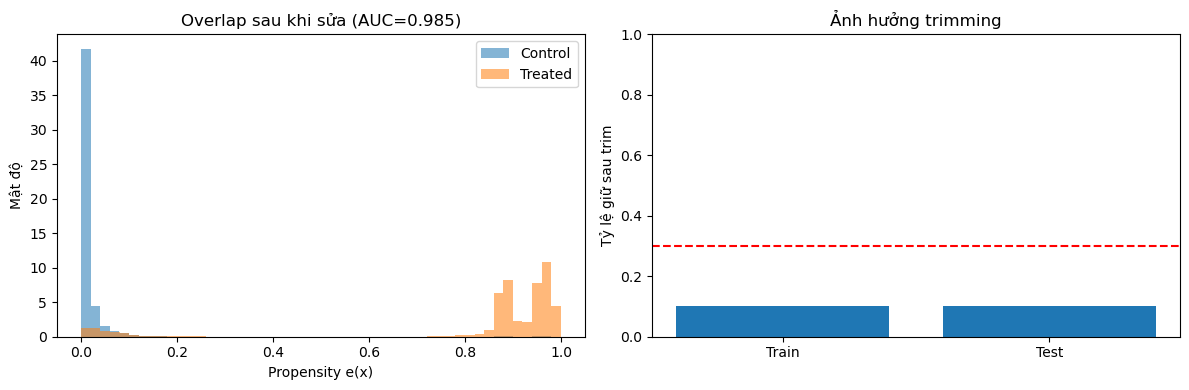


KHÔNG ĐẠT -> dữ liệu này không cho phép ước lượng uplift đáng tin.
   Đừng chạy BƯỚC 2. Chuyển sang Hướng B.
   AUC 0.9846 (cần < 0.85) | giữ 10.3% (cần > 30%)


In [39]:
# =====================================================================
#  HƯỚNG A — BƯỚC 1: thiết kế within-product + chia theo user
#  Chỉ chạy BƯỚC 2 nếu ở đây báo ĐẠT.
# =====================================================================
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

MIN_EACH  = 20            # mỗi sản phẩm cần >= bấy nhiêu treated VÀ control
GATE_AUC  = 0.85          # AUC propensity phải THẤP hơn ngưỡng này
GATE_KEEP = 0.30          # tỷ lệ giữ sau trimming phải CAO hơn ngưỡng này
TRIM      = (0.05, 0.95)

_g = dp.groupby("product_id")["treated"].agg(n="size", n_tr="sum")
_g["n_ct"] = _g["n"] - _g["n_tr"]
SWITCHERS = _g[(_g["n_tr"] >= MIN_EACH) & (_g["n_ct"] >= MIN_EACH)].index
sw_mask = dp["product_id"].isin(SWITCHERS).values

print("=== 1. MẪU SWITCHER ===")
print(f"Sản phẩm switcher      : {len(SWITCHERS):,} / {len(_g):,} "
      f"({len(SWITCHERS)/len(_g):.1%})")
print(f"Decision point giữ lại : {sw_mask.sum():,} / {len(dp):,} ({sw_mask.mean():.1%})")
print(f"Tỷ lệ treated          : {dp.loc[sw_mask,'treated'].mean():.2%} "
      f"(toàn bộ: {dp['treated'].mean():.2%})")
print(f"Tỷ lệ y=1              : {dp.loc[sw_mask,'y'].mean():.2%}")

_uh = pd.util.hash_pandas_object(dp["user_id"], index=False).to_numpy() % 100
usplit = np.where(_uh < 70, "train", np.where(_uh < 85, "val", "test"))

print("\n=== 2. TỶ LỆ TREATED THEO SPLIT ===")
print(f"{'':6s} {'theo THỜI GIAN (cũ)':>22s} {'theo USER (mới)':>20s}")
for s in ["train", "val", "test"]:
    m_old = sw_mask & (dp["split"] == s).values
    m_new = sw_mask & (usplit == s)
    print(f"{s:6s} {dp.loc[m_old,'treated'].mean():>21.2%} "
          f"{dp.loc[m_new,'treated'].mean():>19.2%}")
_r = (dp.loc[sw_mask & (usplit=='test'), 'treated'].mean()
      / max(dp.loc[sw_mask & (usplit=='train'), 'treated'].mean(), 1e-9))
print(f"-> test/train = {_r:.2f}x (cũ: 0.25x). Cần gần 1.0.")

DROP_PROD = ["log_ref", "cv", "days_since_chg"]
INVAR_C   = [c for c in INVAR if c not in DROP_PROD]
print(f"\n=== 3. HIỆP BIẾN ===")
print(f"Bỏ (giá cấp sản phẩm): {DROP_PROD}")
print(f"Giữ ({len(INVAR_C)})  : {INVAR_C}")

_agg_n = flatten_features(np.arange(2)).shape[1] - len(ALL_STAT)
CATE_COLS = (list(range(_agg_n))
             + [_agg_n + ALL_STAT.index(c) for c in INVAR_C])

def cate_features(i):
    """Tổng hợp chuỗi + INVAR_C. KHÔNG chứa treated / d / giá cấp sản phẩm."""
    return flatten_features(i)[:, CATE_COLS]

cidx = {s: np.where(sw_mask & (usplit == s))[0] for s in ["train", "val", "test"]}
for s in cidx:
    print(f"  {s:6s} {len(cidx[s]):>10,}")

T_all = dp["treated"].values.astype(int)

print("\n=== 4. KIỂM TRA OVERLAP ===")
Ztr, Zte = cate_features(cidx["train"]), cate_features(cidx["test"])
Ttr, Tte_c = T_all[cidx["train"]], T_all[cidx["test"]]

ps_c = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                          num_leaves=31, random_state=42, verbose=-1)
ps_c.fit(Ztr, Ttr)
e_tr_c = np.clip(ps_c.predict_proba(Ztr)[:, 1], 1e-6, 1 - 1e-6)
e_te_c = np.clip(ps_c.predict_proba(Zte)[:, 1], 1e-6, 1 - 1e-6)
auc_c  = roc_auc_score(Tte_c, e_te_c)

keep_tr_c = (e_tr_c > TRIM[0]) & (e_tr_c < TRIM[1])
keep_te_c = (e_te_c > TRIM[0]) & (e_te_c < TRIM[1])

print(f"AUC propensity : {auc_c:.4f}   (cũ: 0.9876)")
print(f"Giữ sau trim   : train {keep_tr_c.mean():.1%} | test {keep_te_c.mean():.1%}"
      f"   (cũ test: 3.6%)")
print(f"  trong vùng giữ: treated {Tte_c[keep_te_c].mean():.1%}, "
      f"n = {int(keep_te_c.sum()):,}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for t_, lab in [(0, "Control"), (1, "Treated")]:
    ax[0].hist(e_te_c[Tte_c == t_], bins=50, alpha=.55, density=True, label=lab)
ax[0].set_xlabel("Propensity e(x)"); ax[0].set_ylabel("Mật độ")
ax[0].set_title(f"Overlap sau khi sửa (AUC={auc_c:.3f})"); ax[0].legend()
ax[1].bar(["Train", "Test"], [keep_tr_c.mean(), keep_te_c.mean()])
ax[1].axhline(GATE_KEEP, ls="--", c="r"); ax[1].set_ylim(0, 1)
ax[1].set_ylabel("Tỷ lệ giữ sau trim"); ax[1].set_title("Ảnh hưởng trimming")
plt.tight_layout(); plt.savefig(f"{OUT}/overlap_withinproduct.png", dpi=150); plt.show()

GATE_PASS = (auc_c < GATE_AUC) and (keep_te_c.mean() > GATE_KEEP)
print("\n" + "=" * 60)
if auc_c < GATE_AUC and keep_te_c.mean() > 0.5:
    print("ĐẠT TỐT -> chạy BƯỚC 2.")
elif GATE_PASS:
    print("TẠM ĐẠT -> chạy BƯỚC 2, nhưng phải nêu rõ giới hạn phạm vi "
          "khái quát hoá (chỉ áp dụng cho sản phẩm switcher).")
else:
    print("KHÔNG ĐẠT -> dữ liệu này không cho phép ước lượng uplift đáng tin.")
    print("   Đừng chạy BƯỚC 2. Chuyển sang Hướng B.")
print(f"   AUC {auc_c:.4f} (cần < {GATE_AUC}) | "
      f"giữ {keep_te_c.mean():.1%} (cần > {GATE_KEEP:.0%})")
print("=" * 60)

In [40]:
# =====================================================================
#  HƯỚNG A — CHẨN ĐOÁN: cái gì còn làm lộ treatment (AUC 0.9846)?
#  Nghi ngờ: kênh ch2 của chuỗi = giá_sự_kiện / giá_tham_chiếu, trong khi
#  treatment d = 1 − giá / giá_tham_chiếu. Cùng một đại lượng về đại số.
# =====================================================================
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import roc_auc_score

CATE_NAMES = [FEAT_NAMES[i] for i in CATE_COLS]

print("=== 1. ĐẶC TRƯNG NÀO ĐANG DỰ ĐOÁN TREATMENT? ===")
imp = (pd.Series(ps_c.feature_importances_, index=CATE_NAMES)
       .sort_values(ascending=False))
imp_pct = (imp / imp.sum() * 100).round(1)
print(pd.DataFrame({"importance": imp.head(15), "%": imp_pct.head(15)}).to_string())
print(f"\nTổng % của các đặc trưng ch2 (giá/giá tham chiếu): "
      f"{imp_pct[[n for n in CATE_NAMES if n.endswith('_ch2')]].sum():.1f}%")

CH = lambda c: [n for n in CATE_NAMES if n.endswith(f"_ch{c}")]
SETS = {
    "A. hiện tại":              CATE_NAMES,
    "B. bỏ ch2 (giá)":          [n for n in CATE_NAMES if n not in CH(2)],
    "C. bỏ ch2 + ch1":          [n for n in CATE_NAMES if n not in CH(2) + CH(1)],
    "D. chỉ đếm + lịch + user": [n for n in CATE_NAMES
                                 if n.startswith(("cnt_", "shr_"))
                                 or n in ["seq_len", "dow", "hour", "woy",
                                          "n_hist", "u_rm", "u_bu"]],
}

Fa_tr = flatten_features(cidx["train"])[:, CATE_COLS]
Fa_te = flatten_features(cidx["test"])[:, CATE_COLS]
name2pos = {n: k for k, n in enumerate(CATE_NAMES)}

print("\n=== 2. THỬ CÁC BỘ ĐẶC TRƯNG ===")
print(f"{'bộ':28s} {'n_feat':>7s} {'AUC':>8s} {'giữ sau trim':>14s} {'kết luận':>10s}")
results = {}
for nm, names in SETS.items():
    cols = [name2pos[n] for n in names if n in name2pos]
    if not cols:
        continue
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                           random_state=42, verbose=-1)
    m.fit(Fa_tr[:, cols], Ttr)
    e_ = np.clip(m.predict_proba(Fa_te[:, cols])[:, 1], 1e-6, 1 - 1e-6)
    auc_ = roc_auc_score(Tte_c, e_)
    kp = ((e_ > TRIM[0]) & (e_ < TRIM[1])).mean()
    ok = "ĐẠT" if (auc_ < GATE_AUC and kp > GATE_KEEP) else "không"
    print(f"{nm:28s} {len(cols):>7d} {auc_:>8.4f} {kp:>13.1%} {ok:>10s}")
    results[nm] = {"names": names, "cols": cols, "auc": auc_, "keep": kp,
                   "e": e_, "model": m}

best = None
for nm, r in results.items():
    if r["auc"] < GATE_AUC and r["keep"] > GATE_KEEP:
        best = nm
        break          # ưu tiên bộ ÍT bị lọc nhất mà vẫn đạt

print("\n" + "=" * 62)
if best:
    r = results[best]
    print(f"CHỌN: {best}  (AUC {r['auc']:.4f}, giữ {r['keep']:.1%})")
    CATE_NAMES_FINAL = r["names"]
    CATE_COLS_FINAL  = [CATE_COLS[k] for k in r["cols"]]

    def cate_features(i):
        return flatten_features(i)[:, CATE_COLS_FINAL]

    ps_c   = r["model"]
    e_te_c = r["e"]
    e_tr_c = np.clip(ps_c.predict_proba(Fa_tr[:, r["cols"]])[:, 1], 1e-6, 1 - 1e-6)
    keep_tr_c = (e_tr_c > TRIM[0]) & (e_tr_c < TRIM[1])
    keep_te_c = (e_te_c > TRIM[0]) & (e_te_c < TRIM[1])
    GATE_PASS = True
    print("Đã cập nhật cate_features / ps_c / keep_* -> chạy được BƯỚC 2.")
    print(f"  train giữ {keep_tr_c.mean():.1%} ({int(keep_tr_c.sum()):,}) | "
          f"test giữ {keep_te_c.mean():.1%} ({int(keep_te_c.sum()):,})")
    print("\nPHẢI ghi vào bài: đã loại các đặc trưng phái sinh từ giá khỏi tập")
    print("hiệp biến vì chúng đồng nhất về đại số với biến treatment; nhận dạng")
    print("do đó dựa trên giả định unconfoundedness có điều kiện trên hành vi,")
    print("lịch và lịch sử người dùng — giả định KHÔNG kiểm chứng được.")
else:
    GATE_PASS = False
    print("KHÔNG BỘ NÀO ĐẠT.")
    print("Kể cả khi bỏ hết đặc trưng giá, treatment vẫn bị xác định gần như")
    print("hoàn toàn bởi hiệp biến -> việc giảm giá mang tính hệ thống chứ không")
    print("ngẫu nhiên, không có phản thực. Dừng Hướng A, chuyển Hướng B.")
print("=" * 62)

=== 1. ĐẶC TRƯNG NÀO ĐANG DỰ ĐOÁN TREATMENT? ===
          importance     %
woy             1905  21.2
min_ch2         1201  13.3
max_ch2          762   8.5
dow              656   7.3
mean_ch1         527   5.9
mean_ch2         497   5.5
u_rm             470   5.2
hour             396   4.4
std_ch2          347   3.9
max_ch0          343   3.8
min_ch0          297   3.3
u_bu             249   2.8
mean_ch0         233   2.6
std_ch0          215   2.4
cnt_ev2          162   1.8

Tổng % của các đặc trưng ch2 (giá/giá tham chiếu): 31.2%

=== 2. THỬ CÁC BỘ ĐẶC TRƯNG ===
bộ                            n_feat      AUC   giữ sau trim   kết luận
A. hiện tại                       31   0.9846         10.3%      không
B. bỏ ch2 (giá)                   27   0.9772         11.2%      không
C. bỏ ch2 + ch1                   23   0.9770         11.2%      không
D. chỉ đếm + lịch + user          15   0.9768         11.3%      không

KHÔNG BỘ NÀO ĐẠT.
Kể cả khi bỏ hết đặc trưng giá, treatment vẫn bị xác 

In [41]:
# =====================================================================
#  HƯỚNG A — THỬ CUỐI: thiết kế within (SẢN PHẨM × TUẦN)
#  Không cần propensity model. Đây là ước lượng two-way fixed effects.
# =====================================================================
import numpy as np, pandas as pd

MIN_CELL   = 5      # mỗi ô (sản phẩm, tuần) cần >= bấy nhiêu treated VÀ control
GATE_CELLS = 500    # cần ít nhất bấy nhiêu ô dùng được
GATE_COV   = 0.02   # và bao phủ ít nhất bấy nhiêu % decision point

w = dp["ts"].dt.isocalendar()
dp["_cell"] = (dp["product_id"].astype("int64") * 10000
               + w["year"].astype("int64") % 100 * 100
               + w["week"].astype("int64"))

g = (dp.groupby("_cell")
       .agg(n_tr=("treated", "sum"), n=("treated", "size"))
       .assign(n_ct=lambda x: x["n"] - x["n_tr"]))
usable = g[(g["n_tr"] >= MIN_CELL) & (g["n_ct"] >= MIN_CELL)].index
cell_mask = dp["_cell"].isin(usable).values

print("=== ĐỘ PHỦ CỦA THIẾT KẾ (SẢN PHẨM × TUẦN) ===")
print(f"Tổng số ô            : {len(g):,}")
print(f"Ô dùng được (>= {MIN_CELL} mỗi nhóm): {len(usable):,} ({len(usable)/len(g):.2%})")
print(f"Decision point phủ   : {cell_mask.sum():,} / {len(dp):,} ({cell_mask.mean():.2%})")
if cell_mask.sum():
    print(f"  tỷ lệ treated trong đó: {dp.loc[cell_mask,'treated'].mean():.2%}")
    print(f"  tỷ lệ y=1 trong đó    : {dp.loc[cell_mask,'y'].mean():.2%}")

GATE2_PASS = (len(usable) >= GATE_CELLS) and (cell_mask.mean() >= GATE_COV)

if not GATE2_PASS:
    print("\n" + "=" * 62)
    print("KHÔNG ĐẠT -> Hướng A đã hết phương án.")
    print("Giảm giá gần như không thay đổi trong phạm vi một sản phẩm trong")
    print("cùng một tuần -> không tồn tại phản thực. Đây là giới hạn của DỮ")
    print("LIỆU, không phải của mô hình. Chuyển Hướng B.")
    print("=" * 62)
else:
    sub = dp.loc[cell_mask, ["_cell", "treated", "y", "price_raw", "d"]].copy()
    p = (sub.groupby(["_cell", "treated"])["y"]
            .agg(["mean", "size"]).unstack("treated").dropna())
    diff = (p[("mean", 1.0)] - p[("mean", 0.0)]).to_numpy()
    n1 = p[("size", 1.0)].to_numpy(); n0 = p[("size", 0.0)].to_numpy()
    wgt = n1 * n0 / (n1 + n0)

    ate = float((diff * wgt).sum() / wgt.sum())
    se = float(np.sqrt(((wgt ** 2) * (diff - ate) ** 2).sum()) / wgt.sum())
    lo, hi = ate - 1.96 * se, ate + 1.96 * se
    naive = float(sub.loc[sub.treated == 1, "y"].mean()
                  - sub.loc[sub.treated == 0, "y"].mean())

    print("\n=== ƯỚC LƯỢNG ===")
    print(f"Chênh lệch THÔ (không khử ô)        : {naive:+.5f}")
    print(f"ATE within (sản phẩm × tuần)        : {ate:+.5f}")
    print(f"  KTC 95%                           : [{lo:+.5f}, {hi:+.5f}]")
    print(f"  số ô = {len(diff):,} | n hiệu quả = {wgt.sum():,.0f}")
    print(f"  -> {'KHÁC 0 có ý nghĩa' if lo*hi > 0 else 'KHÔNG khác 0'}")
    print(f"\nĐộ lệch do nhiễu thời điểm/sản phẩm : {naive - ate:+.5f}")
    base = sub.loc[sub.treated == 0, "y"].mean()
    print(f"Quy đổi tương đối: {ate/max(base,1e-9)*100:+.1f}% so với "
          f"tỷ lệ mua nền {base:.2%}")

    print("\n=== ATE THEO MỨC GIẢM GIÁ ===")
    rows = []
    for lo_d, hi_d, lab in [(0.05, 0.10, "5-10%"), (0.10, 0.15, "10-15%"),
                            (0.15, 0.20, "15-20%"), (0.20, 1.00, ">20%")]:
        s2 = sub[(sub.treated == 0) | ((sub.d >= lo_d) & (sub.d < hi_d))]
        p2 = (s2.groupby(["_cell", "treated"])["y"]
                .agg(["mean", "size"]).unstack("treated").dropna())
        if len(p2) < 50:
            rows.append({"mức giảm": lab, "n_ô": len(p2), "ATE": np.nan,
                         "KTC thấp": np.nan, "KTC cao": np.nan}); continue
        d2 = (p2[("mean", 1.0)] - p2[("mean", 0.0)]).to_numpy()
        a2, b2 = p2[("size", 1.0)].to_numpy(), p2[("size", 0.0)].to_numpy()
        w2 = a2 * b2 / (a2 + b2)
        e2 = float((d2 * w2).sum() / w2.sum())
        s2e = float(np.sqrt(((w2 ** 2) * (d2 - e2) ** 2).sum()) / w2.sum())
        rows.append({"mức giảm": lab, "n_ô": len(p2), "ATE": e2,
                     "KTC thấp": e2 - 1.96 * s2e, "KTC cao": e2 + 1.96 * s2e})
    het = pd.DataFrame(rows)
    print(het.round(5).to_string(index=False))

    MARGIN = CONFIG["margin_rate"]
    price_med = float(sub["price_raw"].median())
    het["Δprofit/đơn"] = het.apply(
        lambda r: (r["ATE"] * price_med
                   * (MARGIN - {"5-10%": .075, "10-15%": .125,
                                "15-20%": .175, ">20%": .25}[r["mức giảm"]])
                   if pd.notna(r["ATE"]) else np.nan), axis=1)
    print(f"\n=== LỢI NHUẬN BIÊN (giá trung vị {price_med:.2f}, "
          f"biên gộp {MARGIN:.0%}) ===")
    print(het[["mức giảm", "ATE", "Δprofit/đơn"]].round(4).to_string(index=False))

    het.to_csv(f"{OUT}/ate_within_product_week.csv", index=False)
    print("\n" + "=" * 62)
    print("ĐẠT -> đây là kết quả nhân quả CHÍNH của bài.")
    print("Phạm vi: chỉ sản phẩm có thay đổi giá TRONG cùng một tuần.")
    print("Giả định: trong cùng sản phẩm và cùng tuần, ngày giảm giá là")
    print("as-good-as-random. Yếu hơn nhiều unconfoundedness toàn cục,")
    print("nhưng vẫn KHÔNG kiểm chứng được — phải nêu rõ.")
    print("=" * 62)

=== ĐỘ PHỦ CỦA THIẾT KẾ (SẢN PHẨM × TUẦN) ===
Tổng số ô            : 581,329
Ô dùng được (>= 5 mỗi nhóm): 8,936 (1.54%)
Decision point phủ   : 402,857 / 5,528,714 (7.29%)
  tỷ lệ treated trong đó: 60.43%
  tỷ lệ y=1 trong đó    : 20.72%

=== ƯỚC LƯỢNG ===
Chênh lệch THÔ (không khử ô)        : +0.04068
ATE within (sản phẩm × tuần)        : +0.04021
  KTC 95%                           : [+0.03603, +0.04440]
  số ô = 8,936 | n hiệu quả = 87,696
  -> KHÁC 0 có ý nghĩa

Độ lệch do nhiễu thời điểm/sản phẩm : +0.00047
Quy đổi tương đối: +22.0% so với tỷ lệ mua nền 18.26%

=== ATE THEO MỨC GIẢM GIÁ ===
mức giảm  n_ô     ATE  KTC thấp  KTC cao
   5-10% 4897 0.03343   0.02832  0.03855
  10-15% 2911 0.04838   0.03938  0.05737
  15-20%  935 0.04597   0.03404  0.05790
    >20%  542 0.05472   0.03941  0.07003

=== LỢI NHUẬN BIÊN (giá trung vị 2.49, biên gộp 30%) ===
mức giảm    ATE  Δprofit/đơn
   5-10% 0.0334       0.0187
  10-15% 0.0484       0.0211
  15-20% 0.0460       0.0143
    >20% 0.0547    

In [42]:
# =====================================================================
#  HƯỚNG A — BƯỚC 3: khuyến mãi có lãi ở NHÓM KHÁCH NÀO?
#  Công thức lợi nhuận ĐÚNG (bản trước THIẾU số hạng thứ hai):
#      ΔProfit = P · [ τ·(m − d)  −  p0·d ]
#                       lãi thêm     biên MẤT trên khách vốn đã mua
# =====================================================================
import numpy as np, pandas as pd, lightgbm as lgb
from sklearn.metrics import roc_auc_score

assert GATE2_PASS, "Chỉ chạy sau khi thiết kế product×week báo ĐẠT."

MARGINS = [0.30, 0.40, 0.50, 0.60, 0.70]
MIN_SUB = 3
D_MID   = {"5-10%": 0.075, "10-15%": 0.125, "15-20%": 0.175, ">20%": 0.25}

idx_sub = np.where(cell_mask)[0]
sub = dp.loc[cell_mask, ["_cell", "treated", "y", "price_raw", "d"]].copy()
T_s = sub["treated"].to_numpy().astype(int)
y_s = sub["y"].to_numpy().astype(float)
c_s = sub["_cell"].to_numpy()

_names = [FEAT_NAMES[i] for i in CATE_COLS]
P0_LOCAL = [k for k, n in enumerate(_names)
            if not (n.endswith("_ch2") or n.endswith("_ch1"))]
P0_COLS  = [CATE_COLS[k] for k in P0_LOCAL]
print(f"Đặc trưng dự báo p0: {len(P0_COLS)} cột (đã bỏ ch1, ch2)")

F = flatten_features(idx_sub)[:, P0_COLS]

cells_u = pd.Index(np.unique(c_s))
fold_of = pd.Series(np.random.RandomState(0).randint(0, 2, len(cells_u)),
                    index=cells_u)
fold = pd.Series(c_s).map(fold_of).to_numpy()

p0_hat = np.zeros(len(idx_sub))
for k in [0, 1]:
    tr = (fold != k) & (T_s == 0)
    te = (fold == k)
    mdl = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                             random_state=42, verbose=-1).fit(F[tr], y_s[tr])
    p0_hat[te] = mdl.predict_proba(F[te])[:, 1]

print(f"AUC của mô hình p0 (trên control): "
      f"{roc_auc_score(y_s[T_s == 0], p0_hat[T_s == 0]):.4f}")

qs = np.quantile(p0_hat, [.2, .4, .6, .8])
grp = np.digitize(p0_hat, qs)
sub["_g"] = grp

def within_ate(mask_rows, min_each=MIN_SUB):
    s = pd.DataFrame({"c": c_s[mask_rows], "T": T_s[mask_rows], "y": y_s[mask_rows]})
    p = s.groupby(["c", "T"])["y"].agg(["mean", "size"]).unstack("T").dropna()
    if len(p) == 0:
        return np.nan, np.nan, 0
    n1, n0 = p[("size", 1)].to_numpy(), p[("size", 0)].to_numpy()
    ok = (n1 >= min_each) & (n0 >= min_each)
    if ok.sum() < 30:
        return np.nan, np.nan, int(ok.sum())
    diff = (p[("mean", 1)] - p[("mean", 0)]).to_numpy()[ok]
    n1, n0 = n1[ok], n0[ok]
    w = n1 * n0 / (n1 + n0)
    a = float((diff * w).sum() / w.sum())
    se = float(np.sqrt(((w ** 2) * (diff - a) ** 2).sum()) / w.sum())
    return a, se, int(ok.sum())

rows = []
for q in range(5):
    m_ = (grp == q)
    a, se, nc = within_ate(m_)
    rows.append({"nhóm p0": f"Q{q+1}", "n": int(m_.sum()), "n_ô": nc,
                 "p0 thực tế": float(y_s[m_ & (T_s == 0)].mean()),
                 "ATE": a, "se": se,
                 "giá TB": float(sub.loc[m_, "price_raw"].mean())})
het = pd.DataFrame(rows)
het["KTC thấp"] = het["ATE"] - 1.96 * het["se"]
het["KTC cao"]  = het["ATE"] + 1.96 * het["se"]
print("\n=== ATE THEO NGŨ PHÂN VỊ XÁC SUẤT MUA NỀN ===")
print(het[["nhóm p0", "n", "n_ô", "p0 thực tế", "ATE", "KTC thấp", "KTC cao"]]
      .round(4).to_string(index=False))

print("\n=== τ CẦN ĐỂ HOÀ VỐN (biên gộp 30%) — so với ATE thực tế ===")
be = []
for _, r in het.iterrows():
    row = {"nhóm p0": r["nhóm p0"], "p0": round(r["p0 thực tế"], 4),
           "ATE": round(r["ATE"], 4) if pd.notna(r["ATE"]) else np.nan}
    for lab, d in D_MID.items():
        row[f"cần@{lab}"] = round(r["p0 thực tế"] * d / (0.30 - d), 4)
    be.append(row)
print(pd.DataFrame(be).to_string(index=False))

print("\n=== Δ LỢI NHUẬN/ĐƠN (công thức đúng) — ô có LÃI được đánh dấu * ===")
out = []
for _, r in het.iterrows():
    if pd.isna(r["ATE"]):
        continue
    for m in MARGINS:
        row = {"nhóm p0": r["nhóm p0"], "p0": round(r["p0 thực tế"], 3),
               "biên gộp": f"{m:.0%}"}
        for lab, d in D_MID.items():
            v = r["giá TB"] * (r["ATE"] * (m - d) - r["p0 thực tế"] * d)
            row[lab] = f"{v:+.4f}" + ("*" if v > 0 else "")
        out.append(row)
prof = pd.DataFrame(out)
print(prof.to_string(index=False))

prof.to_csv(f"{OUT}/profit_by_segment.csv", index=False)
het.to_csv(f"{OUT}/ate_by_p0_quintile.csv", index=False)

n_pos = sum(1 for _, r in prof.iterrows() for lab in D_MID if r[lab].endswith("*"))
print("\n" + "=" * 62)
if n_pos:
    print(f"CÓ {n_pos} tổ hợp (nhóm × mức giảm × biên gộp) sinh lãi.")
    print("-> Bài có kết quả 'quyết định khuyến mãi' cụ thể.")
else:
    print("KHÔNG tổ hợp nào sinh lãi ở mọi biên gộp đã thử.")
    print("-> Kết luận: ở bước add-to-cart, khuyến mãi phá biên vì phần lớn")
    print("   khách vốn đã mua. Đối thoại trực tiếp với Ascarza (2018).")
print("=" * 62)

Đặc trưng dự báo p0: 23 cột (đã bỏ ch1, ch2)
AUC của mô hình p0 (trên control): 0.7150

=== ATE THEO NGŨ PHÂN VỊ XÁC SUẤT MUA NỀN ===
nhóm p0     n  n_ô  p0 thực tế     ATE  KTC thấp  KTC cao
     Q1 80572 3187      0.0509  0.0822    0.0756   0.0888
     Q2 80571 2481      0.1198  0.0499    0.0419   0.0579
     Q3 80571 2783      0.1588  0.0417    0.0339   0.0494
     Q4 80571 2917      0.2158  0.0331    0.0236   0.0426
     Q5 80572 2504      0.3741 -0.0065   -0.0198   0.0067

=== τ CẦN ĐỂ HOÀ VỐN (biên gộp 30%) — so với ATE thực tế ===
nhóm p0     p0     ATE  cần@5-10%  cần@10-15%  cần@15-20%  cần@>20%
     Q1 0.0509  0.0822     0.0170      0.0363      0.0712    0.2543
     Q2 0.1198  0.0499     0.0399      0.0855      0.1677    0.5988
     Q3 0.1588  0.0417     0.0529      0.1134      0.2223    0.7939
     Q4 0.2158  0.0331     0.0719      0.1542      0.3022    1.0791
     Q5 0.3741 -0.0065     0.1247      0.2672      0.5238    1.8706

=== Δ LỢI NHUẬN/ĐƠN (công thức đúng) — ô có LÃI

In [43]:
# =====================================================================
#  HƯỚNG A — BƯỚC 4: chính sách tối ưu + kiểm định cân bằng
# =====================================================================
import numpy as np, pandas as pd

D_MID = {"5-10%": 0.075, "10-15%": 0.125, "15-20%": 0.175, ">20%": 0.25}

print("=== CHÍNH SÁCH TỐI ƯU THEO BIÊN GỘP ===")
pol_rows = []
for m in [0.30, 0.40, 0.50, 0.60, 0.70]:
    per_q, choice = [], []
    for _, r in het.iterrows():
        if pd.isna(r["ATE"]):
            per_q.append(0.0); choice.append("—"); continue
        best_v, best_lab = 0.0, "không KM"      # luôn có phương án không làm gì
        for lab, d in D_MID.items():
            v = r["giá TB"] * (r["ATE"] * (m - d) - r["p0 thực tế"] * d)
            if v > best_v:
                best_v, best_lab = v, lab
        per_q.append(best_v); choice.append(best_lab)

    w = het["n"].to_numpy() / het["n"].sum()
    v_opt = float(np.sum(np.array(per_q) * w))
    v_blanket, lab_blanket = -np.inf, None
    for lab, d in D_MID.items():
        vv = float(np.sum([r["giá TB"] * (r["ATE"] * (m - d) - r["p0 thực tế"] * d)
                           for _, r in het.iterrows()] * w))
        if vv > v_blanket:
            v_blanket, lab_blanket = vv, lab
    base_margin = float(np.sum(het["p0 thực tế"] * het["giá TB"] * m * w))

    pol_rows.append({
        "biên gộp": f"{m:.0%}",
        "chính sách": " | ".join(f"{q}:{c}" for q, c in zip(het['nhóm p0'], choice)),
        "% được KM": f"{w[[c != 'không KM' for c in choice]].sum():.0%}",
        "Δ tối ưu": round(v_opt, 4),
        "Δ đại trà": round(v_blanket, 4),
        "% biên gộp (tối ưu)": f"{v_opt/base_margin*100:+.1f}%",
        "% biên gộp (đại trà)": f"{v_blanket/base_margin*100:+.1f}%",
    })
pol = pd.DataFrame(pol_rows)
print(pol[["biên gộp", "% được KM", "Δ tối ưu", "Δ đại trà",
           "% biên gộp (tối ưu)", "% biên gộp (đại trà)"]].to_string(index=False))
print("\nChính sách chi tiết theo nhóm:")
for _, r in pol.iterrows():
    print(f"  biên gộp {r['biên gộp']}: {r['chính sách']}")

het2 = het.copy()
het2["uplift tương đối"] = (het2["ATE"] / het2["p0 thực tế"] * 100).round(1)
print("\n=== UPLIFT TƯƠNG ĐỐI (ATE / p0) ===")
print(het2[["nhóm p0", "p0 thực tế", "ATE", "uplift tương đối"]]
      .round(4).to_string(index=False))
print("Trần cơ học của uplift là (1 − p0); báo cáo cả hai dạng để loại trừ")
print("cách giải thích 'nhóm p0 cao đơn giản là hết chỗ để tăng'.")

print("\n=== KIỂM ĐỊNH CÂN BẰNG (trong ô sản phẩm × tuần) ===")
BAL = [c for c in ["n_hist", "u_rm", "u_bu", "dow", "hour"] if c in ALL_STAT]
Xb = X_stat[idx_sub][:, [ALL_STAT.index(c) for c in BAL]]
df_b = pd.DataFrame(Xb, columns=BAL); df_b["c"], df_b["T"] = c_s, T_s

rows = []
for col in BAL:
    p = df_b.groupby(["c", "T"])[col].agg(["mean", "size"]).unstack("T").dropna()
    if len(p) < 30:
        continue
    diff = (p[("mean", 1)] - p[("mean", 0)]).to_numpy()
    n1, n0 = p[("size", 1)].to_numpy(), p[("size", 0)].to_numpy()
    w = n1 * n0 / (n1 + n0)
    dm = float((diff * w).sum() / w.sum())
    se = float(np.sqrt(((w ** 2) * (diff - dm) ** 2).sum()) / w.sum())
    sd = float(df_b[col].std())
    rows.append({"hiệp biến": col, "chênh lệch trong ô": dm, "se": se,
                 "|t|": abs(dm / max(se, 1e-12)),
                 "chuẩn hoá (d/sd)": dm / max(sd, 1e-12)})
bal = pd.DataFrame(rows)
bal["cân bằng?"] = np.where(bal["chuẩn hoá (d/sd)"].abs() < 0.10, "ĐẠT", "LỆCH")
print(bal.round(4).to_string(index=False))
print("\nQuy ước: |chênh lệch chuẩn hoá| < 0.10 được coi là cân bằng tốt.")

n_bad = int((bal["chuẩn hoá (d/sd)"].abs() >= 0.10).sum())
print("\n" + "=" * 62)
if n_bad == 0:
    print("TẤT CẢ hiệp biến cân bằng -> giả định nhận dạng được củng cố mạnh.")
else:
    print(f"{n_bad} hiệp biến còn LỆCH -> nêu rõ trong Limitations và cân nhắc")
    print("thêm chúng làm biến điều chỉnh trong ước lượng.")
print("=" * 62)

pol.to_csv(f"{OUT}/optimal_policy.csv", index=False)
bal.to_csv(f"{OUT}/covariate_balance.csv", index=False)
het2.to_csv(f"{OUT}/ate_by_p0_quintile.csv", index=False)
print(f"\nĐã lưu optimal_policy.csv, covariate_balance.csv vào {OUT}")

=== CHÍNH SÁCH TỐI ƯU THEO BIÊN GỘP ===
biên gộp % được KM  Δ tối ưu  Δ đại trà % biên gộp (tối ưu) % biên gộp (đại trà)
     30%       40%    0.0137    -0.0150               +6.4%                -7.0%
     40%       60%    0.0263     0.0020               +9.3%                +0.7%
     50%       60%    0.0411     0.0189              +11.6%                +5.3%
     60%       80%    0.0568     0.0359              +13.4%                +8.4%
     70%       80%    0.0742     0.0529              +15.0%               +10.7%

Chính sách chi tiết theo nhóm:
  biên gộp 30%: Q1:5-10% | Q2:5-10% | Q3:không KM | Q4:không KM | Q5:không KM
  biên gộp 40%: Q1:5-10% | Q2:5-10% | Q3:5-10% | Q4:không KM | Q5:không KM
  biên gộp 50%: Q1:5-10% | Q2:5-10% | Q3:5-10% | Q4:không KM | Q5:không KM
  biên gộp 60%: Q1:5-10% | Q2:5-10% | Q3:5-10% | Q4:5-10% | Q5:không KM
  biên gộp 70%: Q1:5-10% | Q2:5-10% | Q3:5-10% | Q4:5-10% | Q5:không KM

=== UPLIFT TƯƠNG ĐỐI (ATE / p0) ===
nhóm p0  p0 thực tế     ATE  upli

In [44]:
# =====================================================================
#  HƯỚNG A — BƯỚC 5: khử hiệu ứng THỨ TRONG TUẦN (và giờ)
#  Không thể chia ô thành sản phẩm×tuần×thứ (mỗi ô còn 1 ngày, hết phản
#  thực). Cách đúng: thêm FE cho thứ và giờ, khử trung bình luân phiên.
# =====================================================================
import numpy as np, pandas as pd

D_MID = {"5-10%": 0.075, "10-15%": 0.125, "15-20%": 0.175, ">20%": 0.25}

dow_s   = dp.loc[cell_mask, "ts"].dt.dayofweek.to_numpy()
hour_s  = dp.loc[cell_mask, "ts"].dt.hour.to_numpy()
d_s     = sub["d"].to_numpy()
price_s = sub["price_raw"].to_numpy()


def _demean(v, groups, n_iter=15, tol=1e-10):
    v = np.asarray(v, dtype=float).copy()
    for _ in range(n_iter):
        v0 = v.copy()
        for gcode in groups:
            v -= np.bincount(gcode, weights=v)[gcode] / np.bincount(gcode)[gcode]
        if np.max(np.abs(v - v0)) < tol:
            break
    return v


def twfe_ate(rows, use_dow=True, use_hour=True):
    """ATE two-way FE + SE gộp cụm theo ô."""
    if rows.sum() < 1000:
        return np.nan, np.nan, 0
    cc = pd.factorize(c_s[rows])[0]
    groups = [cc]
    if use_dow:
        groups.append(pd.factorize(dow_s[rows])[0])
    if use_hour:
        groups.append(pd.factorize(hour_s[rows])[0])

    yt = _demean(y_s[rows], groups)
    Tt = _demean(T_s[rows].astype(float), groups)
    den = float((Tt ** 2).sum())
    if den <= 0:
        return np.nan, np.nan, 0
    ate = float((Tt * yt).sum() / den)
    e = yt - ate * Tt
    sc = np.bincount(cc, weights=Tt * e)
    se = float(np.sqrt((sc ** 2).sum()) / den)
    return ate, se, int(cc.max() + 1)


all_rows = np.ones(len(y_s), dtype=bool)

print("=== ATE TỔNG THỂ: SO SÁNH CÁC ĐẶC TẢ ===")
base_ate = None
for nm, kw in [("chỉ ô (như bước trước)", dict(use_dow=False, use_hour=False)),
               ("ô + thứ",                dict(use_dow=True,  use_hour=False)),
               ("ô + thứ + giờ",          dict(use_dow=True,  use_hour=True))]:
    a, se, nc = twfe_ate(all_rows, **kw)
    if base_ate is None:
        base_ate = a
    print(f"  {nm:24s} ATE={a:+.5f}  KTC95%[{a-1.96*se:+.5f}, {a+1.96*se:+.5f}]")
a_full, se_full, _ = twfe_ate(all_rows)
print(f"\nThay đổi do khử thứ+giờ: {a_full - base_ate:+.5f} "
      f"({(a_full-base_ate)/max(abs(base_ate),1e-9)*100:+.1f}%)")

print("\n=== ATE THEO NGŨ PHÂN VỊ p0 (đã khử ô + thứ + giờ) ===")
rows_ = []
for q in range(5):
    m_ = (grp == q)
    a, se, nc = twfe_ate(m_)
    rows_.append({"nhóm p0": f"Q{q+1}", "n": int(m_.sum()), "n_ô": nc,
                  "p0 thực tế": float(y_s[m_ & (T_s == 0)].mean()),
                  "ATE": a, "se": se,
                  "KTC thấp": a - 1.96 * se, "KTC cao": a + 1.96 * se,
                  "giá TB": float(price_s[m_].mean())})
het_adj = pd.DataFrame(rows_)
het_adj["uplift tương đối"] = (het_adj["ATE"] / het_adj["p0 thực tế"] * 100).round(1)

cmp_ = het_adj[["nhóm p0", "p0 thực tế", "ATE", "KTC thấp", "KTC cao",
                "uplift tương đối"]].copy()
cmp_["ATE cũ (chưa khử thứ)"] = het["ATE"].to_numpy()
cmp_["thay đổi"] = cmp_["ATE"] - cmp_["ATE cũ (chưa khử thứ)"]
print(cmp_.round(4).to_string(index=False))

print("\n=== CÂN BẰNG SAU KHI KHỬ (chênh lệch trên phần dư) ===")
BAL = [c for c in ["n_hist", "u_rm", "u_bu"] if c in ALL_STAT]
gp = [pd.factorize(c_s)[0], pd.factorize(dow_s)[0], pd.factorize(hour_s)[0]]
Tt_all = _demean(T_s.astype(float), gp)
rows_b = []
for col in BAL + ["dow", "hour"]:
    v = (dow_s.astype(float) if col == "dow" else
         hour_s.astype(float) if col == "hour" else
         X_stat[idx_sub][:, ALL_STAT.index(col)].astype(float))
    vt = _demean(v, gp)
    coef = float((Tt_all * vt).sum() / (Tt_all ** 2).sum())
    rows_b.append({"hiệp biến": col, "chênh lệch sau khử": coef,
                   "chuẩn hoá": coef / max(float(v.std()), 1e-12)})
bal2 = pd.DataFrame(rows_b)
bal2["cân bằng?"] = np.where(bal2["chuẩn hoá"].abs() < 0.10, "ĐẠT", "LỆCH")
print(bal2.round(4).to_string(index=False))

print("\n=== CHÍNH SÁCH TỐI ƯU (dùng ATE đã khử thứ+giờ) ===")
pol_rows = []
for m in [0.30, 0.40, 0.50, 0.60, 0.70]:
    per_q, choice = [], []
    for _, r in het_adj.iterrows():
        best_v, best_lab = 0.0, "không KM"
        for lab, d in D_MID.items():
            v = r["giá TB"] * (r["ATE"] * (m - d) - r["p0 thực tế"] * d)
            if v > best_v:
                best_v, best_lab = v, lab
        per_q.append(best_v); choice.append(best_lab)
    w = het_adj["n"].to_numpy() / het_adj["n"].sum()
    v_opt = float(np.sum(np.array(per_q) * w))
    v_bl = max(float(np.sum([r["giá TB"] * (r["ATE"] * (m - d)
                                            - r["p0 thực tế"] * d)
                             for _, r in het_adj.iterrows()] * w))
               for d in D_MID.values())
    base_m = float(np.sum(het_adj["p0 thực tế"] * het_adj["giá TB"] * m * w))
    pol_rows.append({"biên gộp": f"{m:.0%}",
                     "chính sách": " | ".join(f"{q}:{c}" for q, c in
                                              zip(het_adj['nhóm p0'], choice)),
                     "Δ tối ưu": round(v_opt, 4), "Δ đại trà": round(v_bl, 4),
                     "% biên (tối ưu)": f"{v_opt/base_m*100:+.1f}%",
                     "% biên (đại trà)": f"{v_bl/base_m*100:+.1f}%"})
pol_adj = pd.DataFrame(pol_rows)
print(pol_adj[["biên gộp", "Δ tối ưu", "Δ đại trà",
               "% biên (tối ưu)", "% biên (đại trà)"]].to_string(index=False))
for _, r in pol_adj.iterrows():
    print(f"  biên gộp {r['biên gộp']}: {r['chính sách']}")

het_adj.to_csv(f"{OUT}/ate_by_p0_quintile_adjusted.csv", index=False)
pol_adj.to_csv(f"{OUT}/optimal_policy_adjusted.csv", index=False)
bal2.to_csv(f"{OUT}/covariate_balance_adjusted.csv", index=False)

print("\n" + "=" * 62)
print("Dùng BỘ SỐ NÀY cho bài báo, không dùng bộ chưa khử thứ.")
print("Method phải ghi: two-way fixed effects (sản phẩm×tuần, thứ, giờ),")
print("sai số chuẩn gộp cụm theo ô sản phẩm×tuần.")
print("=" * 62)

=== ATE TỔNG THỂ: SO SÁNH CÁC ĐẶC TẢ ===
  chỉ ô (như bước trước)   ATE=+0.04021  KTC95%[+0.03603, +0.04440]
  ô + thứ                  ATE=+0.05229  KTC95%[+0.04548, +0.05910]
  ô + thứ + giờ            ATE=+0.05077  KTC95%[+0.04400, +0.05754]

Thay đổi do khử thứ+giờ: +0.01056 (+26.3%)

=== ATE THEO NGŨ PHÂN VỊ p0 (đã khử ô + thứ + giờ) ===
nhóm p0  p0 thực tế    ATE  KTC thấp  KTC cao  uplift tương đối  ATE cũ (chưa khử thứ)  thay đổi
     Q1      0.0509 0.0790    0.0703   0.0877             155.3                 0.0822   -0.0032
     Q2      0.1198 0.0543    0.0424   0.0662              45.3                 0.0499    0.0044
     Q3      0.1588 0.0568    0.0433   0.0703              35.8                 0.0417    0.0151
     Q4      0.2158 0.0474    0.0322   0.0627              22.0                 0.0331    0.0143
     Q5      0.3741 0.0103   -0.0107   0.0314               2.8                -0.0065    0.0168

=== CÂN BẰNG SAU KHI KHỬ (chênh lệch trên phần dư) ===
hiệp biến  chênh 

In [45]:
# =====================================================================
#  HƯỚNG A — BƯỚC 6: τ theo NHÓM × MỨC GIẢM, và bảng chính sách đúng
#  Bảng trước dùng MỘT τ cho mỗi nhóm rồi áp cho mọi mức giảm -> ngầm giả
#  định τ không phụ thuộc d, trái với dose-response. Ở đây sửa lại.
# =====================================================================
import numpy as np, pandas as pd

BANDS = [("5-10%", 0.05, 0.10, 0.075), ("10-15%", 0.10, 0.15, 0.125),
         ("15-20%", 0.15, 0.20, 0.175), (">20%", 0.20, 1.01, 0.25)]
MARGINS = [0.30, 0.40, 0.50, 0.60, 0.70]
MIN_N = 3000

print("=== DOSE-RESPONSE TỔNG THỂ (TWFE: ô + thứ + giờ) ===")
dr = []
for lab, lo, hi, dmid in BANDS:
    rows = (T_s == 0) | ((T_s == 1) & (d_s >= lo) & (d_s < hi))
    a, se, nc = twfe_ate(rows)
    dr.append({"mức giảm": lab, "d giữa dải": dmid,
               "n_treated": int(((T_s == 1) & (d_s >= lo) & (d_s < hi)).sum()),
               "n_ô": nc, "τ̂": a, "KTC thấp": a - 1.96 * se,
               "KTC cao": a + 1.96 * se})
dose = pd.DataFrame(dr)
print(dose.round(4).to_string(index=False))

print("\n=== τ̂ THEO NHÓM × MỨC GIẢM ===")
grid, grid_se = {}, {}
for q in range(5):
    key = f"Q{q+1}"
    grid[key], grid_se[key] = {}, {}
    for lab, lo, hi, dmid in BANDS:
        rows = (grp == q) & ((T_s == 0) |
                             ((T_s == 1) & (d_s >= lo) & (d_s < hi)))
        n_tr = int(((grp == q) & (T_s == 1) & (d_s >= lo) & (d_s < hi)).sum())
        if rows.sum() < MIN_N or n_tr < 300:
            grid[key][lab], grid_se[key][lab] = np.nan, np.nan
            continue
        a, se, _ = twfe_ate(rows)
        grid[key][lab], grid_se[key][lab] = a, se

gdf = pd.DataFrame(grid).T
gse = pd.DataFrame(grid_se).T
gdf.insert(0, "p0", het_adj["p0 thực tế"].to_numpy())
print(gdf.round(4).to_string())
print("\n(se kèm theo:)")
print(gse.round(4).to_string())

print("\n=== CHÍNH SÁCH TỐI ƯU (τ riêng cho từng mức giảm) ===")
w = het_adj["n"].to_numpy() / het_adj["n"].sum()
p0v = het_adj["p0 thực tế"].to_numpy()
pv = het_adj["giá TB"].to_numpy()

pol_rows, detail_rows = [], []
for m in MARGINS:
    per_q, choice = [], []
    for qi, key in enumerate([f"Q{i+1}" for i in range(5)]):
        best_v, best_lab = 0.0, "không KM"
        for lab, lo, hi, dmid in BANDS:
            tau = grid[key][lab]
            if np.isnan(tau):
                continue
            v = pv[qi] * (tau * (m - dmid) - p0v[qi] * dmid)
            detail_rows.append({"biên gộp": f"{m:.0%}", "nhóm": key,
                                "mức giảm": lab, "τ̂": round(tau, 4),
                                "Δprofit": round(v, 4)})
            if v > best_v:
                best_v, best_lab = v, lab
        per_q.append(best_v); choice.append(best_lab)

    v_opt = float(np.sum(np.array(per_q) * w))
    v_bl = -np.inf
    for lab, lo, hi, dmid in BANDS:
        vals = []
        for qi, key in enumerate([f"Q{i+1}" for i in range(5)]):
            tau = grid[key][lab]
            vals.append(0.0 if np.isnan(tau)
                        else pv[qi] * (tau * (m - dmid) - p0v[qi] * dmid))
        v_bl = max(v_bl, float(np.sum(np.array(vals) * w)))
    base_m = float(np.sum(p0v * pv * m * w))

    pol_rows.append({"biên gộp": f"{m:.0%}",
                     "chính sách": " | ".join(f"{k}:{c}" for k, c in
                                              zip(gdf.index, choice)),
                     "% được KM": f"{w[[c != 'không KM' for c in choice]].sum():.0%}",
                     "Δ tối ưu": round(v_opt, 4), "Δ đại trà": round(v_bl, 4),
                     "% biên (tối ưu)": f"{v_opt/base_m*100:+.1f}%",
                     "% biên (đại trà)": f"{v_bl/base_m*100:+.1f}%"})

pol6 = pd.DataFrame(pol_rows)
print(pol6[["biên gộp", "% được KM", "Δ tối ưu", "Δ đại trà",
            "% biên (tối ưu)", "% biên (đại trà)"]].to_string(index=False))
print("\nChính sách chi tiết:")
for _, r in pol6.iterrows():
    print(f"  biên gộp {r['biên gộp']}: {r['chính sách']}")

print("\n=== SO SÁNH VỚI BẢNG CŨ (τ không đổi theo d) ===")
cmp6 = pol6[["biên gộp", "Δ tối ưu"]].copy()
cmp6["Δ tối ưu (bảng cũ)"] = pol_adj["Δ tối ưu"].to_numpy()
cmp6["chênh lệch"] = cmp6["Δ tối ưu"] - cmp6["Δ tối ưu (bảng cũ)"]
print(cmp6.round(4).to_string(index=False))

dose.to_csv(f"{OUT}/dose_response_twfe.csv", index=False)
gdf.to_csv(f"{OUT}/tau_grid.csv")
pol6.to_csv(f"{OUT}/optimal_policy_final.csv", index=False)
pd.DataFrame(detail_rows).to_csv(f"{OUT}/policy_detail.csv", index=False)

print("\n" + "=" * 62)
print("Đây là BẢNG CHÍNH SÁCH CUỐI CÙNG cho bài báo.")
print("Table cần có: p0, τ̂ theo mức giảm (kèm KTC), mức giảm tối ưu, Δ biên gộp.")
print("=" * 62)

=== DOSE-RESPONSE TỔNG THỂ (TWFE: ô + thứ + giờ) ===
mức giảm  d giữa dải  n_treated  n_ô     τ̂  KTC thấp  KTC cao
   5-10%       0.075     130968 8936 0.0464    0.0381   0.0548
  10-15%       0.125      70748 8936 0.0513    0.0409   0.0616
  15-20%       0.175      26038 8936 0.0512    0.0356   0.0667
    >20%       0.250      15708 8936 0.0576    0.0405   0.0747

=== τ̂ THEO NHÓM × MỨC GIẢM ===
        p0   5-10%  10-15%  15-20%    >20%
Q1  0.0509  0.0744  0.0799  0.0998  0.0877
Q2  0.1198  0.0525  0.0644  0.0512  0.0468
Q3  0.1588  0.0572  0.0580  0.0478  0.0513
Q4  0.2158  0.0397  0.0356  0.0425  0.0527
Q5  0.3741  0.0096  0.0128  0.0194  0.0320

(se kèm theo:)
     5-10%  10-15%  15-20%    >20%
Q1  0.0057  0.0070  0.0097  0.0124
Q2  0.0074  0.0095  0.0147  0.0146
Q3  0.0087  0.0099  0.0137  0.0177
Q4  0.0094  0.0114  0.0166  0.0200
Q5  0.0129  0.0153  0.0211  0.0288

=== CHÍNH SÁCH TỐI ƯU (τ riêng cho từng mức giảm) ===
biên gộp % được KM  Δ tối ưu  Δ đại trà % biên (tối ưu) % bi